# Tier x: are scale, rotation and alignment linear combinations of each other?

This notebook is Zain's side study beside Tier 1. It follows the plan in `docs/zain_tierx_plan.md` section by section. The plan asks whether the three timing variables of the report carry three separate pieces of information, and where the kernel goes when it turns.

**The three terms.** All three are computed on the centred probe kernel $\tilde K_t = H K_t H$ with $H = I - \tfrac1n \mathbf 1\mathbf 1^\top$, following Cortes, Mohri and Rostamizadeh (2012), Lemma 1, and the report's Kernel metrics section.

- The scale term $S_t = \log(\lVert\tilde K_t\rVert_F / \lVert\tilde K_0\rVert_F)$ depends on the size of the kernel only.
- The rotation term $R_t = 1 - \langle k_t, k_0\rangle$ depends on the unit kernel $k_t = \tilde K_t/\lVert\tilde K_t\rVert_F$ only.
- The centred alignment $A_t = \langle k_t, g\rangle$ with $g$ the unit centred target Gram matrix $H Y Y^\top H$ also depends on the unit kernel only.

**The data.**

- The Tier 1 grid: 63 runs of 100,000 steps at width 100, with a checkpoint every 500 steps.
- Three traced runs at alpha 1 from `ntk_trace.py`, with decay 0, 0.0003 and 0.001. Each holds 175 checkpoints, every 250 steps plus 60 log-spaced steps, and keeps the kernel, the weights and every intermediate at each one. The plan lists four more traced runs at alpha 0.5 and 2. They are not trained yet, so Sections 4 to 6 use the three alpha 1 runs.
- Every run uses the mixed probe of the report: 203 training pairs and all 53 test pairs. The appendix shows why the probe and the kernel definition changed on 24 September 2026.

**How to run it.** The trace arrays are about 65 MB each and git ignores them. Before running this notebook on a fresh checkout, run `uv run python ntk_trace.py 1` from `repoduced-code`, which takes about a minute. The saved outputs below can be read without it.

**How to read it.** Every figure has a markdown cell above it. The cell says what the figure shows and what result would count against the claim it supports. Every figure also has a printed table next to it, so no number has to be read off a plot.

**Sections.** 1 the question and the identity. 2 along a run. 3 at the generalisation event. 4 the traced runs. 5 where the turn goes. 6 the eigenvectors. 7 a synthetic control. 8 what this means for the report and the deck. Appendix: the kernel and probe checks.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter

import ntk_lib as L                # training loop, crossings, kernel terms and plot helpers shared by the tier notebooks
import ntk_trace as T              # the per-checkpoint traces and the Tracer that measures them
import term_dependence as TD       # the identity check and the E1 fits on the grid
import kernel_snapshots as KS      # names of the dense runs, which keep the training-pair probe
from common import kernels         # numpy kernel helpers shared with the animations; ntk_trace puts them on the path

L.set_plot_style()
np.set_printoptions(precision=4, suppress=True, linewidth=140)

# Colours. Blue, orange and aqua are the categorical order of ntk_lib. Yellow is the fourth slot of the same
# reference palette, used only where four things need names (the four subspaces). Gray marks reference lines only.
YELLOW = "#eda100"
SUBSPACE_COLOURS = dict(zip(T.SUBSPACES, [L.BLUE, L.ORANGE, L.AQUA, YELLOW]))
# The traced runs are coloured along the ordered ramp by decay, as the animation scenes colour the dense runs.
# Sections 2 and 3 colour the five grid decays along the same ramp, as the Tier 1 notebook does.
TRACED = [(1.0, 0.0), (1.0, 3e-4), (1.0, 1e-3)]
TRACE_COLOURS = {0.0: L.RAMP[0], 3e-4: L.RAMP[2], 1e-3: L.RAMP[4]}
GRID_DECAYS = [0.0, 1e-5, 3e-5, 1e-4, 3e-4]
GRID_COLOURS = dict(zip(GRID_DECAYS, L.RAMP))
ALPHAS = [0.5, 1.0, 2.0]
ALPHA_STYLE = {0.5: (L.RAMP[0], "o"), 1.0: (L.RAMP[2], "s"), 2.0: (L.RAMP[4], "^")}
DIVERGING = LinearSegmentedColormap.from_list("blue_gray_red", ["#1c5cab", "#f0efec", "#e34948"])
SEQUENTIAL = LinearSegmentedColormap.from_list("blue", ["#cde2fb", "#86b6ef", "#2a78d6", "#184f95", "#0d366b"])
TEST_ACC_LEVEL = TD.TEST_ACC_LEVEL  # the generalisation event is the first checkpoint at test accuracy 1


def label(ek):
    return f"decay {ek:g}"


def decades(ax, which="x"):
    # Label only the powers of ten on a log axis that spans many decades, so that labels do not collide.
    axis = ax.xaxis if which == "x" else ax.yaxis
    axis.set_major_locator(LogLocator(base=10, numticks=12))
    axis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}" if v >= 1 else f"{v:g}"))
    axis.set_minor_formatter(NullFormatter())


# The Tier 1 grid, every run with the mixed probe.
grid = TD.grid_runs()
# The traced runs: the arrays, the run JSON with the history, the schema, and a Tracer for recomputing things.
traces, trace_runs, schemas, tracers = {}, {}, {}, {}
for alpha, ek in TRACED:
    name = T.run_name(alpha, ek)
    traces[ek], schemas[ek] = T.load(name)
    trace_runs[ek] = json.loads((L.RESULTS / f"{name}.json").read_text())
    tracers[ek] = T.Tracer({**L.DEFAULTS, **T.run_config(alpha, ek, 30000)})
    tracers[ek].measure(0, traces[ek]["K"][0])  # keeps the step 0 kernel, so split() can be used later
# The dense runs have the same weights as the traced runs but the old training-pair probe.
dense = {ek: json.loads((L.RESULTS / f"{KS.run_name(ek)}.json").read_text()) for _, ek in TRACED}
events = {ek: L.accuracy_crossings(trace_runs[ek], TEST_ACC_LEVEL) for _, ek in TRACED}

print(f"Grid runs loaded: {len(grid)}, probes {sorted({r['config']['probe'] for r in grid.values()})}")
for a in ALPHAS:
    decays = sorted({r['config']['eta_kappa'] for r in grid.values() if r['config']['alpha'] == a})
    print(f"  alpha {a:g}: {sum(r['config']['alpha'] == a for r in grid.values())} runs, decays {[f'{d:g}' for d in decays]}")
print("Traced runs:")
for alpha, ek in TRACED:
    a, s = traces[ek], schemas[ek]
    ev = events[ek]
    print(f"  {s['run']}: {len(a['step'])} checkpoints, probe {int((~a['probe_is_test']).sum())} training + "
          f"{int(a['probe_is_test'].sum())} test pairs, top k {s['conventions']['top_k']}, "
          f"memorisation at step {ev['t_train']}, generalisation at step {ev['t_test']}")
print("First checkpoints of a trace:", traces[0.0]["step"][:24].tolist())

Grid runs loaded: 63, probes ['mixed']
  alpha 0.5: 20 runs, decays ['0', '1e-05', '3e-05', '0.0001', '0.00012', '0.0003', '0.0004', '0.0012']
  alpha 1: 18 runs, decays ['0', '1e-05', '3e-05', '0.0001', '0.0003', '0.001']
  alpha 2: 20 runs, decays ['0', '7.5e-06', '1e-05', '2.5e-05', '3e-05', '7.5e-05', '0.0001', '0.0003']
Traced runs:
  trace_N100_a1_wd0_s0: 175 checkpoints, probe 203 training + 53 test pairs, top k 88, memorisation at step 4250, generalisation at step 16750
  trace_N100_a1_wd0.0003_s0: 175 checkpoints, probe 203 training + 53 test pairs, top k 88, memorisation at step 4500, generalisation at step 8500
  trace_N100_a1_wd0.001_s0: 175 checkpoints, probe 203 training + 53 test pairs, top k 88, memorisation at step None, generalisation at step None
First checkpoints of a trace: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 14, 16, 19, 23, 28, 33, 39, 47, 56, 66, 79, 94, 112]


## 1. The question and the identity

The phrase "linear combination" hides four different claims. The plan names them L1 to L4.

- **L1, by definition.** Does one term follow from the other two by construction?
- **L2, along a run.** Does one term follow another along a single training run?
- **L3, across runs at the event.** Do the three values at the generalisation event lie on one plane?
- **L4, in matrix space.** Does the kernel turn inside the plane spanned by its start and the target?

**L1 is settled by algebra.** The scale term uses the norm of $\tilde K_t$ and nothing else. The rotation term and the alignment use the unit kernel $k_t$ and nothing else. So the scale term cannot be recovered from the other two, and they cannot be recovered from it.

Rotation and alignment are tied by an exact identity. Split $k_t$ into its part along $k_0$ and a remainder $v_t$ orthogonal to $k_0$. The part along $k_0$ has length $1 - R_t$ and the remainder has length $\sqrt{R_t(2 - R_t)}$. Let $g_\perp$ be the part of $g$ orthogonal to $k_0$, made unit length, and call the cosine between $v_t$ and $g_\perp$ the aim $\gamma_t$. Taking the inner product with $g$ gives

$$A_t = A_0 (1 - R_t) + \gamma_t \sqrt{1 - A_0^2}\,\sqrt{R_t (2 - R_t)}.$$

This identity is the group's own algebra, from the docstring of `term_dependence.py`. It is not taken from a paper. Given $A_0$, the triple $(S_t, R_t, \gamma_t)$ carries the same information as $(S_t, R_t, A_t)$.

**What would count against it.** The identity is algebra. A miss larger than floating-point rounding would mean a bug in the code. The first check below uses the dense runs, where the aim is computed once from the saved kernels and once from the recorded terms.

In [2]:
# The identity check of term_dependence.py on the dense runs (training-pair probe, kernel every 250 steps).
TD.check_identity()
print()
# The checks each trace wrote into its schema when it was made. All of them should sit at rounding level.
for _, ek in TRACED:
    print(schemas[ek]["run"])
    for check, value in schemas[ek]["checks"].items():
        print(f"  {check:>45}: largest difference {value:.1e}")

1. The identity on the dense runs
  dense_N100_a1_wd0.0003_s0: largest difference 5.8e-06 over 120 checkpoints


  dense_N100_a1_wd0.001_s0: largest difference 3.9e-06 over 120 checkpoints
  dense_N100_a1_wd0_s0: largest difference 9.1e-06 over 120 checkpoints

trace_N100_a1_wd0_s0
                S against the history field S_c: largest difference 1.4e-06
                R against the history field R_c: largest difference 3.1e-06
                A against the history field A_t: largest difference 6.9e-07
      A_uncentred against the history field A_u: largest difference 3.4e-07
        D^2 against exp2S_term + 1 - cross_term: largest difference 1.4e-14
          the three shares against a sum of one: largest difference 3.3e-16
                         share_k0 against R / 2: largest difference 2.2e-16
        share_gperp against gamma^2 (1 - R / 2): largest difference 4.3e-18
                     A against the aim identity: largest difference 1.7e-16
trace_N100_a1_wd0.0003_s0
                S against the history field S_c: largest difference 1.9e-06
                R against the history field 

**Figure 1.1. The identity on the traced runs.** Left: the measured alignment $A_t$ as lines and the alignment rebuilt from $A_0$, $R_t$ and $\gamma_t$ as dots, for the three traced runs. Right: the absolute miss between the two on a log scale. The claim is that the miss is at float64 rounding, about $10^{-16}$. A miss of $10^{-6}$ or more would count against it.

trace_N100_a1_wd0_s0: largest miss 1.7e-16, median miss 4.2e-17
trace_N100_a1_wd0.0003_s0: largest miss 1.4e-16, median miss 5.6e-17
trace_N100_a1_wd0.001_s0: largest miss 1.4e-16, median miss 4.2e-17


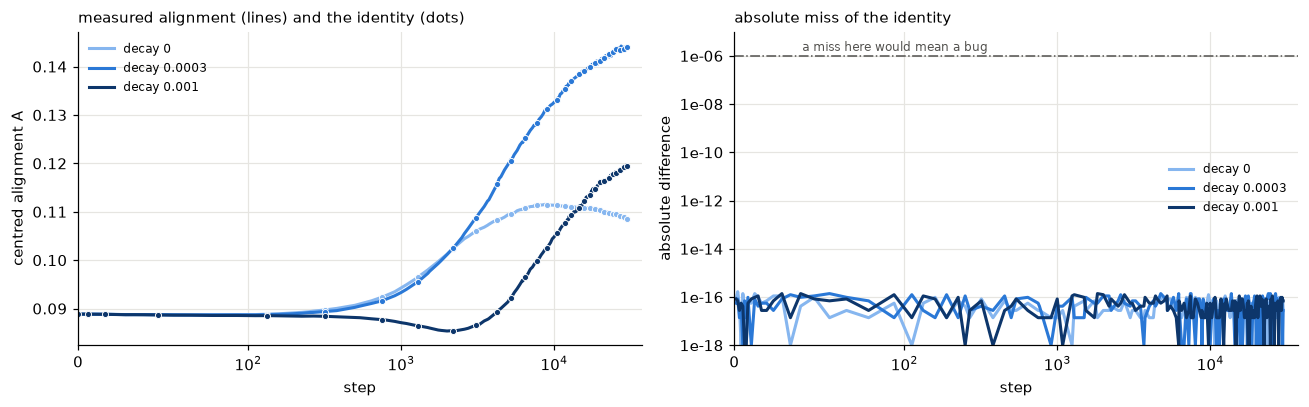

In [3]:
def rebuild_alignment(a):
    # A_t from the identity, with A_0 at step 0 where the aim is undefined.
    A_0, R, gamma = float(a["A_0"]), a["R"], a["gamma"]
    rebuilt = A_0 * (1 - R) + gamma * np.sqrt(1 - A_0 ** 2) * np.sqrt(np.clip(R * (2 - R), 0, None))
    rebuilt[0] = A_0
    return rebuilt

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for _, ek in TRACED:
    a = traces[ek]
    steps, rebuilt = a["step"], rebuild_alignment(a)
    miss = np.abs(a["A"] - rebuilt)[1:]
    axes[0].plot(steps, a["A"], color=TRACE_COLOURS[ek], label=label(ek))
    axes[0].plot(steps[::6], rebuilt[::6], "o", ms=4, color=TRACE_COLOURS[ek], markeredgecolor="white", markeredgewidth=0.6)
    axes[1].plot(steps[1:], np.maximum(miss, 1e-18), color=TRACE_COLOURS[ek], label=label(ek))
    print(f"{schemas[ek]['run']}: largest miss {miss.max():.1e}, median miss {np.median(miss):.1e}")
axes[0].set_title("measured alignment (lines) and the identity (dots)", loc="left", fontsize=10)
axes[0].set_ylabel("centred alignment A")
axes[1].set_yscale("log")
axes[1].set_ylim(1e-18, 1e-5)
axes[1].axhline(1e-6, color=L.GRAY, lw=1, ls="-.")
axes[1].text(40, 1.6e-6, "a miss here would mean a bug", color=L.GRAY, fontsize=8)
axes[1].set_title("absolute miss of the identity", loc="left", fontsize=10)
axes[1].set_ylabel("absolute difference")
for ax in axes:
    ax.set_xlabel("step")
    L.log_step_axis(ax)
    L.tidy_axes(ax)
    ax.legend(fontsize=8)
decades(axes[1], "y")
fig.tight_layout()

**Figure 1.2. Where the alignment gain comes from.** The identity writes $A_t$ as two parts. The first, $A_0(1 - R_t)$, can only shrink as the kernel turns. The second, $\gamma_t\sqrt{1 - A_0^2}\sqrt{R_t(2 - R_t)}$, grows only when the turn points at the target. Each panel shows one traced run with the two parts and their sum. The claim is that every gain in alignment is carried by the second part. A run whose alignment rose while the second part stayed flat would count against it, and it cannot happen if the identity holds.

trace_N100_a1_wd0_s0 at step 30000: A 0.1086 = start part 0.0826 + aim part 0.0260; A_0 0.0888, R 0.0704, aim 0.0709
trace_N100_a1_wd0.0003_s0 at step 30000: A 0.1441 = start part 0.0824 + aim part 0.0617; A_0 0.0888, R 0.0723, aim 0.1659
trace_N100_a1_wd0.001_s0 at step 30000: A 0.1195 = start part 0.0831 + aim part 0.0364; A_0 0.0888, R 0.0642, aim 0.1037


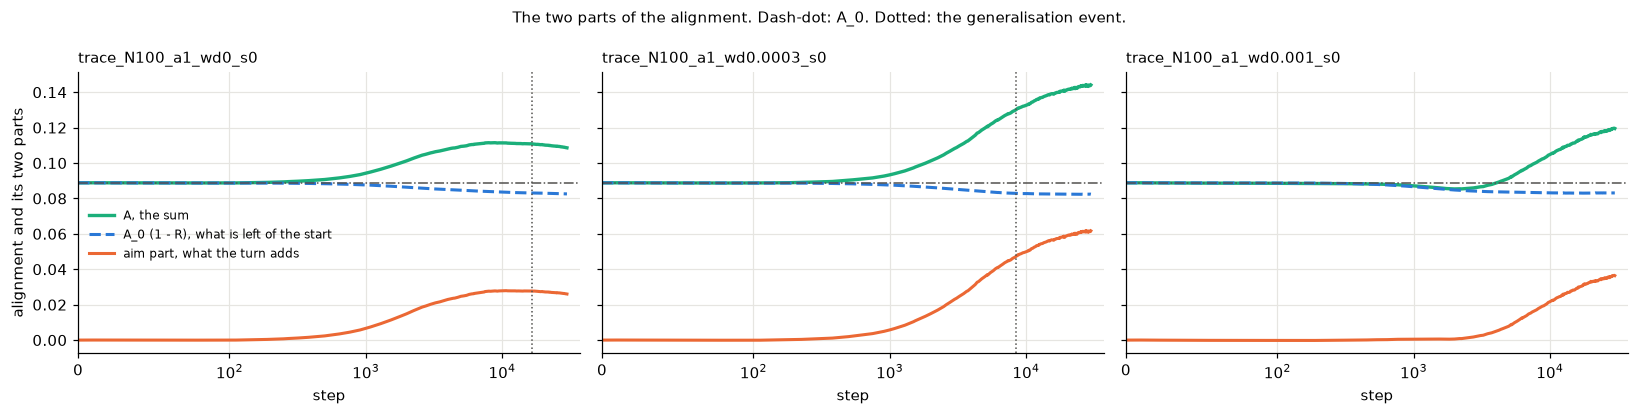

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
for ax, (_, ek) in zip(axes, TRACED):
    a = traces[ek]
    A_0, R, gamma = float(a["A_0"]), a["R"], np.nan_to_num(a["gamma"])
    start_part = A_0 * (1 - R)
    turn_part = gamma * np.sqrt(1 - A_0 ** 2) * np.sqrt(np.clip(R * (2 - R), 0, None))
    ax.plot(a["step"], a["A"], color=L.AQUA, lw=2.2, label="A, the sum")
    ax.plot(a["step"], start_part, color=L.BLUE, ls="--", label="A_0 (1 - R), what is left of the start")
    ax.plot(a["step"], turn_part, color=L.ORANGE, label="aim part, what the turn adds")
    ax.axhline(A_0, color=L.GRAY, lw=1, ls="-.")
    if events[ek]["t_test"] is not None:
        ax.axvline(events[ek]["t_test"], color=L.GRAY, lw=1, ls=":")
    ax.set_title(f"{schemas[ek]['run']}", loc="left", fontsize=10)
    ax.set_xlabel("step")
    L.log_step_axis(ax)
    L.tidy_axes(ax)
    i = -1
    print(f"{schemas[ek]['run']} at step {a['step'][i]}: A {a['A'][i]:.4f} = start part {start_part[i]:.4f} "
          f"+ aim part {turn_part[i]:.4f}; A_0 {A_0:.4f}, R {R[i]:.4f}, aim {gamma[i]:.4f}")
axes[0].set_ylabel("alignment and its two parts")
axes[0].legend(fontsize=8, loc="center left", bbox_to_anchor=(0, 0.42))
fig.suptitle("The two parts of the alignment. Dash-dot: A_0. Dotted: the generalisation event.", fontsize=10)
fig.tight_layout()

**Figure 1.3. The movement statistic and Equation eq:decomp.** The report writes the squared movement of the kernel as $D_t^2 = e^{2S_t} + 1 - 2e^{S_t}(1 - R_t)$. Here it is applied to the centred kernel. The left panel shows $D_t$ for each traced run. The right panel shows the pieces $e^{2S_t}$ and $2e^{S_t}(1 - R_t)$, whose difference plus one is $D_t^2$. The claim is that the equation holds exactly and that $D_t$ is dominated by scale. If $D_t$ moved while $e^{2S_t}$ stayed flat, rotation would be driving it.

trace_N100_a1_wd0_s0: largest miss of Equation eq:decomp 1.4e-14; at the last step D 4.147, exp(2S) 25.606, 2 exp(S)(1 - R) 9.408, D if R were 0: 4.060
trace_N100_a1_wd0.0003_s0: largest miss of Equation eq:decomp 2.0e-15; at the last step D 1.083, exp(2S) 3.779, 2 exp(S)(1 - R) 3.607, D if R were 0: 0.944
trace_N100_a1_wd0.001_s0: largest miss of Equation eq:decomp 4.4e-16; at the last step D 0.447, exp(2S) 0.436, 2 exp(S)(1 - R) 1.236, D if R were 0: 0.340


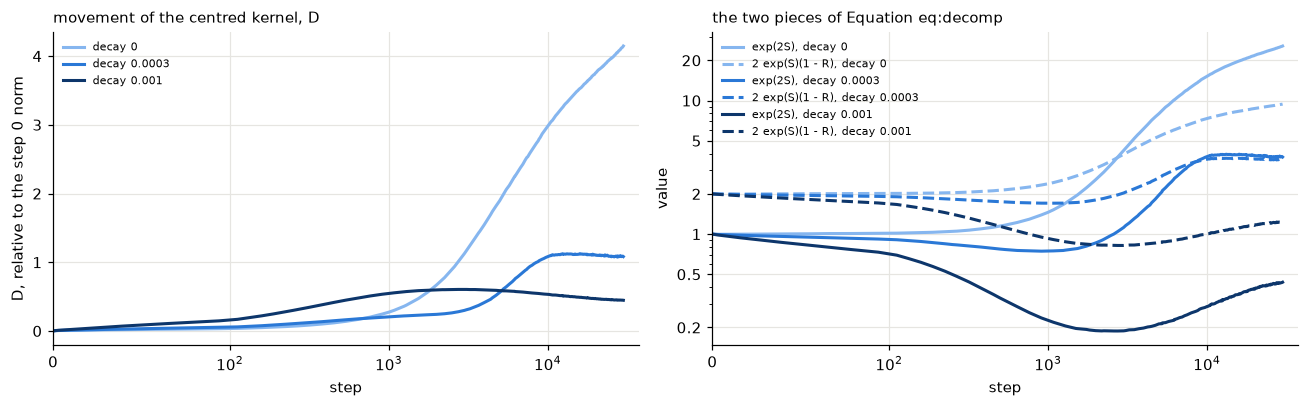

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for _, ek in TRACED:
    a = traces[ek]
    axes[0].plot(a["step"], a["D"], color=TRACE_COLOURS[ek], label=label(ek))
    axes[1].plot(a["step"], a["exp2S_term"], color=TRACE_COLOURS[ek], label=f"exp(2S), {label(ek)}")
    axes[1].plot(a["step"], a["cross_term"], color=TRACE_COLOURS[ek], ls="--", label=f"2 exp(S)(1 - R), {label(ek)}")
    miss = np.abs(a["D"] ** 2 - (a["exp2S_term"] + 1 - a["cross_term"])).max()
    i = -1
    print(f"{schemas[ek]['run']}: largest miss of Equation eq:decomp {miss:.1e}; at the last step D {a['D'][i]:.3f}, "
          f"exp(2S) {a['exp2S_term'][i]:.3f}, 2 exp(S)(1 - R) {a['cross_term'][i]:.3f}, "
          f"D if R were 0: {abs(np.exp(a['S'][i]) - 1):.3f}")
axes[0].set_title("movement of the centred kernel, D", loc="left", fontsize=10)
axes[0].set_ylabel("D, relative to the step 0 norm")
axes[1].set_title("the two pieces of Equation eq:decomp", loc="left", fontsize=10)
axes[1].set_ylabel("value")
axes[1].set_yscale("log")
for ax in axes:
    ax.set_xlabel("step")
    L.log_step_axis(ax)
    L.tidy_axes(ax)
    ax.legend(fontsize=7)
fig.tight_layout()

## 2. Along a run (experiment E1 on the grid)

**Claim L2.** Along one run, does a straight line in the rotation term predict the scale term? Does a straight line in the rotation term, or in its square root, predict the alignment? The identity says the alignment is linear in $\sqrt{R_t}$ for small $R_t$ only when the aim is constant, so the square root is the fairer test for alignment.

**The test.** For every grid run, the share of variance that a least-squares line explains, $R^2$, for three pairs: scale on rotation, alignment on rotation, and alignment on the square root of rotation. One table per pair, by decay level.

**Kill criterion, from the plan.** The claim that scale and rotation are one variable fails if the median share of scale on rotation falls below 0.9 at any decay level.

In [6]:
along = TD.lockstep(grid)
print()
by_decay = {}
for r in along:
    by_decay.setdefault(r["eta_kappa"], []).append(r["S_t on R_t"])
failing = [ek for ek, v in sorted(by_decay.items()) if np.median(v) < 0.9]
print("Decay levels where the median R squared of S_t on R_t is below 0.9:", [f"{ek:g}" for ek in failing])
print("So the claim that scale and rotation are one variable", "fails." if failing else "survives.")


2. Along each run: R squared of S_t on R_t
  eta kappa runs    min median    max
          0   20  0.897  0.993  0.998
    7.5e-06    1  0.997  0.997  0.997
      1e-05    9  0.954  0.987  0.997
    2.5e-05    1  0.980  0.980  0.980
      3e-05    9  0.857  0.944  0.992
    7.5e-05    1  0.952  0.952  0.952
     0.0001    9  0.662  0.850  0.947
    0.00012    1  0.817  0.817  0.817
     0.0003    9  0.371  0.923  0.933
     0.0004    1  0.922  0.922  0.922
      0.001    1  0.036  0.036  0.036
     0.0012    1  0.528  0.528  0.528

2. Along each run: R squared of A_t on R_t
  eta kappa runs    min median    max
          0   20  0.000  0.032  0.590
    7.5e-06    1  0.575  0.575  0.575
      1e-05    9  0.257  0.762  0.995
    2.5e-05    1  0.991  0.991  0.991
      3e-05    9  0.452  0.948  0.994
    7.5e-05    1  0.980  0.980  0.980
     0.0001    9  0.445  0.829  0.978
    0.00012    1  0.479  0.479  0.479
     0.0003    9  0.621  0.814  0.885
     0.0004    1  0.801  0.801  0.801


**Figure 2.1. The three shares for every grid run.** Each panel is one of the three pairs. The horizontal position is the decay level, each dot is one run, and the colour and marker give alpha. The short black bar is the median at each decay level. The dash-dot line on the left panel is the kill level of 0.9. A median bar below that line at any decay level counts against the claim that scale and rotation are one variable.

alpha    decay seed  S on R  A on R A on sqrt R
  0.5        0    0   0.989   0.121       0.020
  0.5    1e-05    0   0.987   0.257       0.396
  0.5    3e-05    0   0.919   0.807       0.790
  0.5   0.0001    0   0.782   0.445       0.392
  0.5  0.00012    0   0.817   0.479       0.419
  0.5   0.0003    0   0.928   0.702       0.604
  0.5   0.0004    0   0.922   0.801       0.691
  0.5   0.0012    0   0.528   0.772       0.660
    1        0    0   0.992   0.000       0.031
    1    1e-05    0   0.994   0.627       0.754
    1    3e-05    0   0.928   0.959       0.897
    1   0.0001    0   0.850   0.829       0.730
    1   0.0003    0   0.923   0.844       0.742
    1    0.001    0   0.036   0.373       0.270
  1.5        0    0   0.992   0.036       0.133
    2        0    0   0.997   0.028       0.115
    2  7.5e-06    0   0.997   0.575       0.732
    2    1e-05    0   0.994   0.863       0.940
    2  2.5e-05    0   0.980   0.991       0.959
    2    3e-05    0   0.979   0.991     

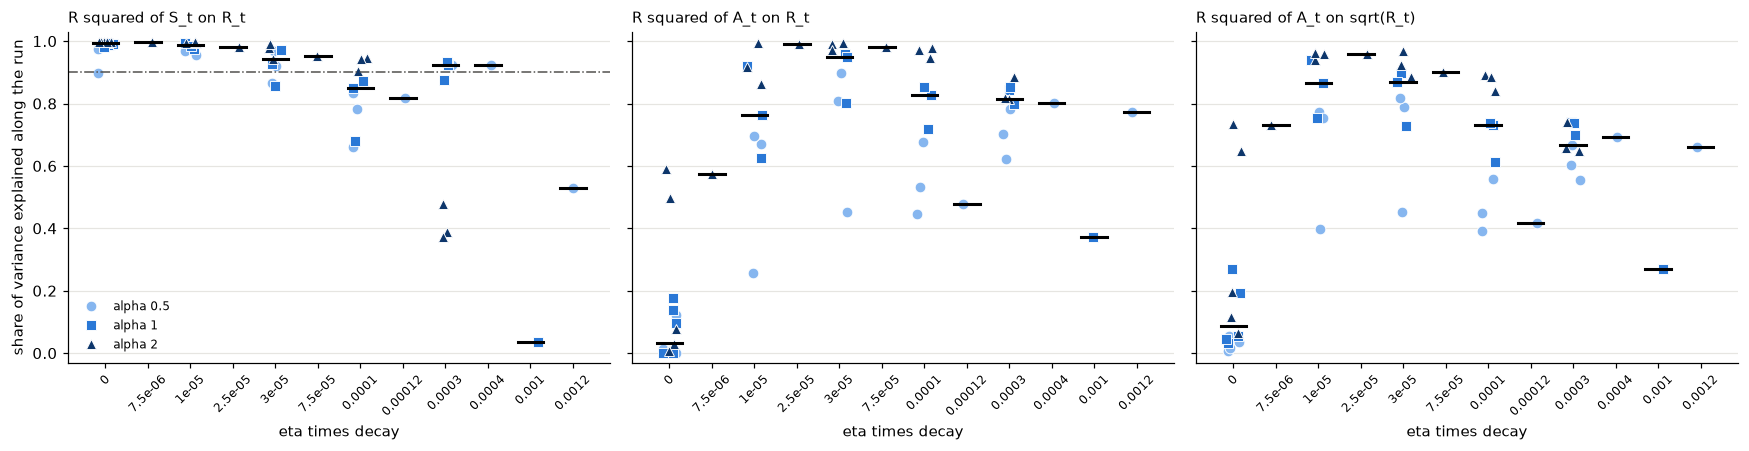

In [7]:
decays_all = sorted({r["eta_kappa"] for r in along})
position = {ek: i for i, ek in enumerate(decays_all)}
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for ax, (share, _, _) in zip(axes, TD.SHARES):
    for alpha in ALPHAS:
        colour, marker = ALPHA_STYLE[alpha]
        pts = [(position[r["eta_kappa"]] + rng.uniform(-0.18, 0.18), r[share]) for r in along if r["alpha"] == alpha]
        if pts:
            x, y = zip(*pts)
            ax.plot(x, y, marker, ls="none", ms=7, color=colour, markeredgecolor="white", markeredgewidth=0.6,
                    label=f"alpha {alpha:g}")
    for ek in decays_all:
        med = np.median([r[share] for r in along if r["eta_kappa"] == ek])
        ax.plot([position[ek] - 0.3, position[ek] + 0.3], [med, med], color="black", lw=2)
    ax.set_xticks(range(len(decays_all)))
    ax.set_xticklabels([f"{ek:g}" for ek in decays_all], rotation=45, fontsize=8)
    ax.set_xlabel("eta times decay")
    ax.set_title(f"R squared of {share}", loc="left", fontsize=10)
    ax.set_ylim(-0.03, 1.03)
    ax.grid(axis="x", visible=False)
axes[0].axhline(0.9, color=L.GRAY, lw=1, ls="-.")
axes[0].set_ylabel("share of variance explained along the run")
axes[0].legend(fontsize=8, loc="lower left")
fig.tight_layout()

print(f"{'alpha':>5} {'decay':>8} {'seed':>4} {'S on R':>7} {'A on R':>7} {'A on sqrt R':>11}")
for r in sorted(along, key=lambda r: (r["alpha"], r["eta_kappa"], r["seed"])):
    if r["seed"] == 0:
        print(f"{r['alpha']:>5g} {r['eta_kappa']:>8g} {r['seed']:>4} {r['S_t on R_t']:7.3f} {r['A_t on R_t']:7.3f} "
              f"{r['A_t on sqrt(R_t)']:11.3f}")

**Figure 2.2. Scale against rotation along each seed 0 run.** One panel per alpha. Each line is one decay level, drawn from step 0 to the end of the run, and the dot marks the generalisation event. If scale and rotation were one variable, every line would be straight and all lines would lie on one curve. Lines that bend, or that separate by decay, count against it.

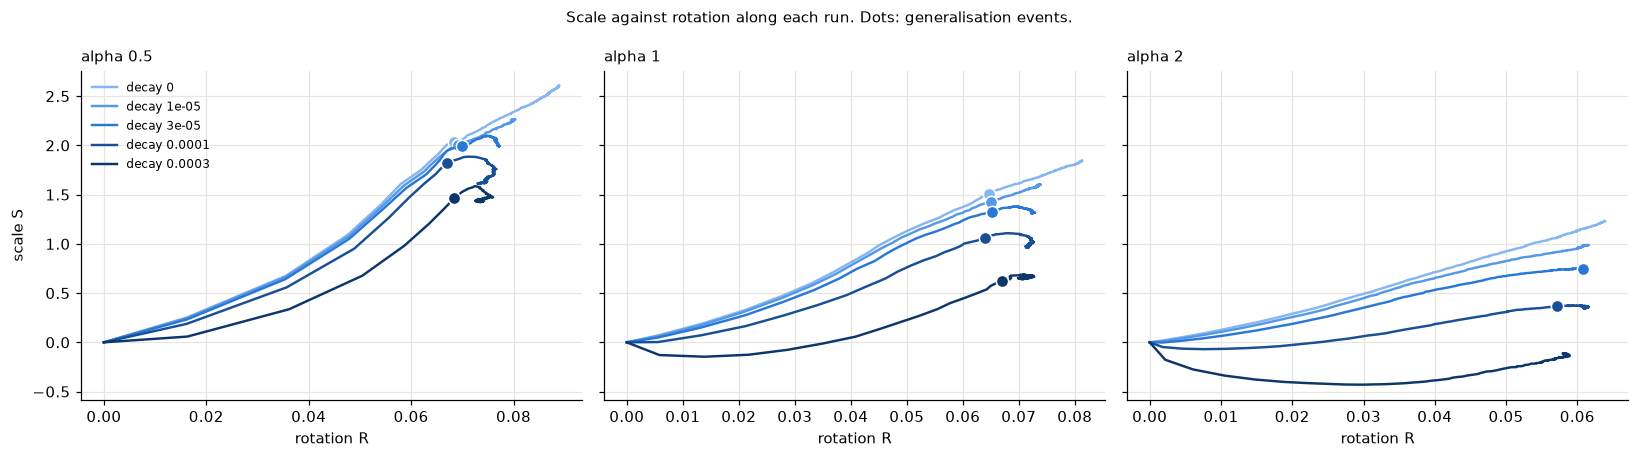

In [8]:
def seed0(alpha, ek):
    return grid.get(L.cell_name(100, alpha, ek, 0))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, alpha in zip(axes, ALPHAS):
    for ek in GRID_DECAYS:
        run = seed0(alpha, ek)
        if run is None:
            continue
        h = run["history"]
        ax.plot(h["R_c"], h["S_c"], color=GRID_COLOURS[ek], label=label(ek), lw=1.6)
        t = L.accuracy_crossings(run, TEST_ACC_LEVEL)["t_test"]
        if t is not None:
            ax.plot([L.value_at_step(run, "R_c", t)], [L.value_at_step(run, "S_c", t)], "o", ms=8,
                    color=GRID_COLOURS[ek], markeredgecolor="white")
    ax.set_title(f"alpha {alpha:g}", loc="left", fontsize=10)
    ax.set_xlabel("rotation R")
    L.tidy_axes(ax)
axes[0].set_ylabel("scale S")
axes[0].legend(fontsize=8)
fig.suptitle("Scale against rotation along each run. Dots: generalisation events.", fontsize=10)
fig.tight_layout()

**Figure 2.3. Alignment against the square root of rotation.** Same layout as Figure 2.2. The identity makes this relation a straight line only when the aim stays constant along the run. So a curve that bends shows the aim changing during training. Straight lines at every decay level would count against the claim that the aim carries information of its own.

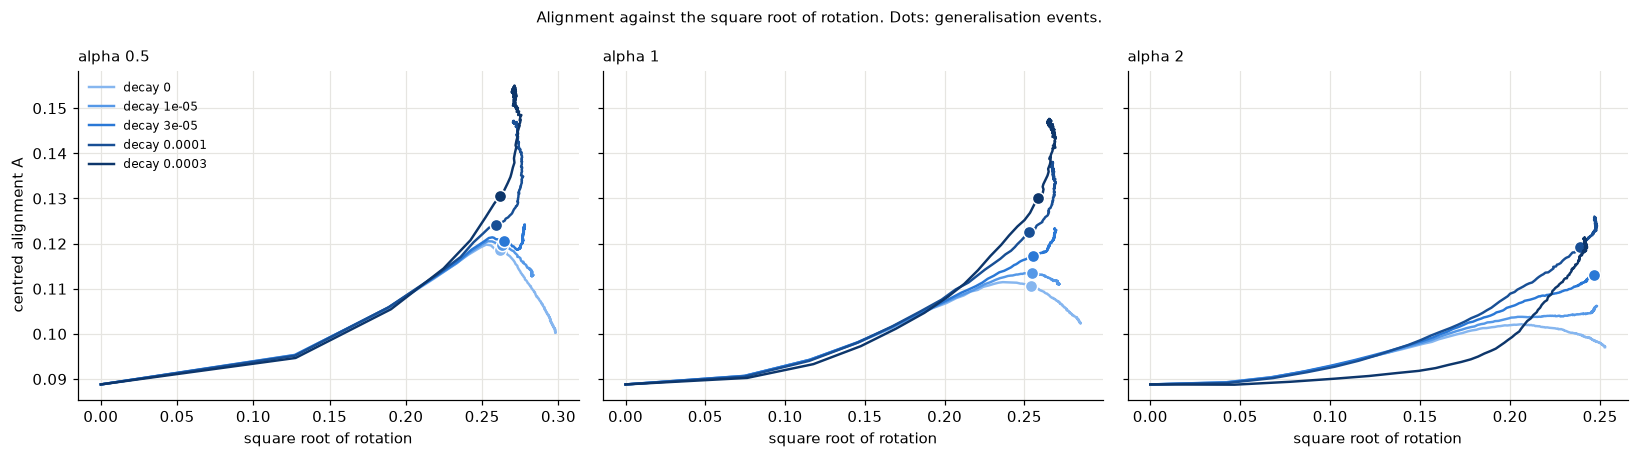

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, alpha in zip(axes, ALPHAS):
    for ek in GRID_DECAYS:
        run = seed0(alpha, ek)
        if run is None:
            continue
        h = run["history"]
        ax.plot(np.sqrt(np.clip(h["R_c"], 0, None)), h["A_t"], color=GRID_COLOURS[ek], label=label(ek), lw=1.6)
        t = L.accuracy_crossings(run, TEST_ACC_LEVEL)["t_test"]
        if t is not None:
            ax.plot([np.sqrt(max(L.value_at_step(run, "R_c", t), 0))], [L.value_at_step(run, "A_t", t)], "o", ms=8,
                    color=GRID_COLOURS[ek], markeredgecolor="white")
    ax.set_title(f"alpha {alpha:g}", loc="left", fontsize=10)
    ax.set_xlabel("square root of rotation")
    L.tidy_axes(ax)
axes[0].set_ylabel("centred alignment A")
axes[0].legend(fontsize=8)
fig.suptitle("Alignment against the square root of rotation. Dots: generalisation events.", fontsize=10)
fig.tight_layout()

## 3. At the generalisation event (experiment E1 across runs)

**Claim L3.** At the generalisation event, are the three terms linearly dependent across runs? The event is the first checkpoint at test accuracy 1, as in the Tier 1 notebook.

**The test.** A least-squares fit of the alignment at the event on the scale and the rotation at the event, with an intercept, over every run that has an event. The share of variance it explains gets a bootstrap interval over runs.

**Kill criterion, from the plan.** The claim that the terms at the event are linearly dependent fails if the share is below 0.5.

For contrast, the same fit is also run on rotation and the aim. The identity ties those two to the alignment exactly, so that fit should explain almost all of it.

In [10]:
event = TD.at_event(grid)
S_ev = np.array([r["S"] for r in event]); R_ev = np.array([r["R"] for r in event])
A_ev = np.array([r["A"] for r in event]); g_ev = np.array([r["gamma"] for r in event])
A0_ev = np.array([r["A_0"] for r in event])
turn_ev = g_ev * np.sqrt(1 - A0_ev ** 2) * np.sqrt(R_ev * (2 - R_ev))
fits = {
    "S and R (the plane of L3)": TD.plane_fit(A_ev, np.c_[S_ev, R_ev]),
    "S alone": TD.plane_fit(A_ev, S_ev[:, None]),
    "R alone": TD.plane_fit(A_ev, R_ev[:, None]),
    "the aim alone": TD.plane_fit(A_ev, g_ev[:, None]),
    "R and the aim": TD.plane_fit(A_ev, np.c_[R_ev, g_ev]),
    "the two terms of the identity": TD.plane_fit(A_ev, np.c_[A0_ev * (1 - R_ev), turn_ev]),
}
print(f"\n{'A at the event fitted on':>32} {'R squared':>9} {'95% interval':>17}")
for name, f in fits.items():
    print(f"{name:>32} {f['r2']:9.3f} {f['lo']:8.3f} to {f['hi']:.3f}")
plane = fits["S and R (the plane of L3)"]
print(f"\nKill criterion for L3: share below 0.5. The plane explains {plane['r2']:.3f}, "
      f"so the claim that the terms at the event are linearly dependent {'fails' if plane['r2'] < 0.5 else 'survives'}.")


3. The terms at the generalisation event, test accuracy 1
  45 of 63 runs have an event.
       term    mean     min     max max/min sd/mean
        S_t  1.3576  0.3220  2.1038    6.53   0.405
        R_t  0.0666  0.0547  0.0811    1.48   0.079
        A_t  0.1191  0.0991  0.1448    1.46   0.071
    gamma_t  0.1040  0.0452  0.1613    3.57   0.217
  Correlations over runs, in the order S_t, R_t, A_t, gamma_t:
   +1.00 +0.54 -0.31 -0.37
   +0.54 +1.00 +0.07 -0.04
   -0.31 +0.07 +1.00 +0.99
   -0.37 -0.04 +0.99 +1.00
  Mean aim at the event, by alpha and decay:
   alpha 0.5: 0 -> 0.098 (5), 1e-05 -> 0.099 (3), 3e-05 -> 0.103 (3), 0.0001 -> 0.114 (3), 0.00012 -> 0.117 (1), 0.0003 -> 0.135 (3), 0.0004 -> 0.135 (1), 0.0012 -> 0.161 (1)
   alpha 1: 0 -> 0.068 (5), 1e-05 -> 0.082 (3), 3e-05 -> 0.095 (3), 0.0001 -> 0.113 (3), 0.0003 -> 0.137 (3)
   alpha 2: 2.5e-05 -> 0.085 (1), 3e-05 -> 0.090 (3), 7.5e-05 -> 0.108 (1), 0.0001 -> 0.114 (3)
  Plane fit of A_t on S_t and R_t with an intercept: R


        A at the event fitted on R squared      95% interval
       S and R (the plane of L3)     0.172    0.024 to 0.568
                         S alone     0.095    0.005 to 0.251
                         R alone     0.005    0.000 to 0.267
                   the aim alone     0.976    0.962 to 0.987
                   R and the aim     0.988    0.982 to 0.993
   the two terms of the identity     1.000    1.000 to 1.000

Kill criterion for L3: share below 0.5. The plane explains 0.172, so the claim that the terms at the event are linearly dependent fails.


**Figure 3.1. Alignment against rotation at the event.** Each point is one run that generalised. The colour is the scale term at the event, and the marker is alpha. If the three terms lay on a plane, the colour would change smoothly across the cloud, and the points would lie on a line in each colour band. A scattered cloud with mixed colours counts against L3.

alpha    decay seed   step       S       R       A     aim
  0.5        0    0   5500   2.033  0.0685  0.1186  0.0990
  0.5        0    1   6000   2.021  0.0699  0.1152  0.0933
  0.5        0    2   5000   1.980  0.0698  0.1162  0.0965
  0.5        0    3   4000   1.887  0.0616  0.1198  0.1114
  0.5        0    4   6000   2.104  0.0708  0.1145  0.0876
  0.5    1e-05    0   5500   2.007  0.0692  0.1196  0.1016
  0.5    1e-05    1   5500   1.971  0.0693  0.1162  0.0964
  0.5    1e-05    2   5000   1.963  0.0691  0.1172  0.0993
  0.5    3e-05    0   6000   1.993  0.0699  0.1207  0.1040
  0.5    3e-05    1   5000   1.904  0.0685  0.1174  0.1001
  0.5    3e-05    2   4500   1.886  0.0682  0.1192  0.1053
  0.5   0.0001    0   4500   1.818  0.0671  0.1240  0.1148
  0.5   0.0001    1   4500   1.764  0.0677  0.1214  0.1115
  0.5   0.0001    2   4000   1.738  0.0686  0.1235  0.1171
  0.5  0.00012    0   4000   1.746  0.0659  0.1246  0.1172
  0.5   0.0003    0   3500   1.463  0.0684  0.1306  0.13

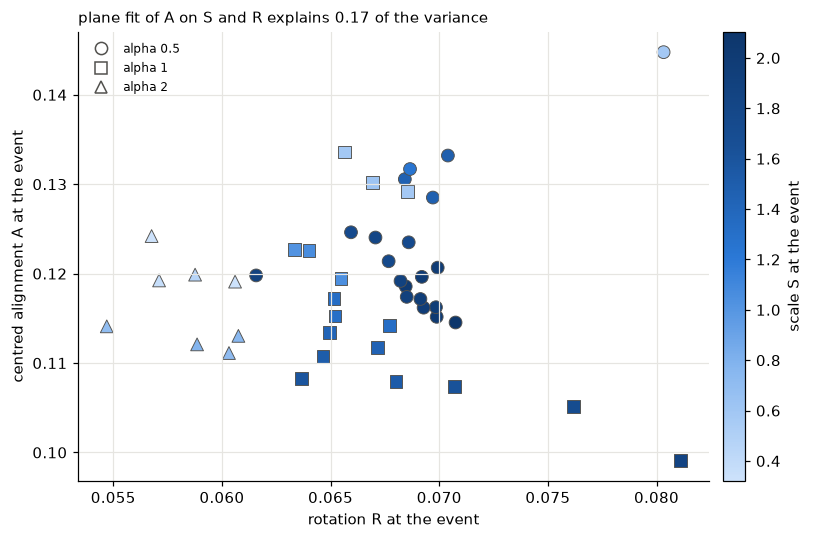

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 5))
vmin, vmax = S_ev.min(), S_ev.max()
for alpha in ALPHAS:
    sel = np.array([r["alpha"] == alpha for r in event])
    sc = ax.scatter(R_ev[sel], A_ev[sel], c=S_ev[sel], cmap=SEQUENTIAL, vmin=vmin, vmax=vmax, s=70,
                    marker=ALPHA_STYLE[alpha][1], edgecolor=L.GRAY, lw=0.6, label=f"alpha {alpha:g}")
fig.colorbar(sc, ax=ax, fraction=0.05, pad=0.02).set_label("scale S at the event")
ax.set_xlabel("rotation R at the event")
ax.set_ylabel("centred alignment A at the event")
ax.set_title(f"plane fit of A on S and R explains {plane['r2']:.2f} of the variance", loc="left", fontsize=10)
ax.legend(handles=[Line2D([], [], marker=ALPHA_STYLE[al][1], ls="none", ms=8, markerfacecolor="white",
                          markeredgecolor=L.GRAY, label=f"alpha {al:g}") for al in ALPHAS], fontsize=8, loc="upper left")
L.tidy_axes(ax)
fig.tight_layout()
print(f"{'alpha':>5} {'decay':>8} {'seed':>4} {'step':>6} {'S':>7} {'R':>7} {'A':>7} {'aim':>7}")
for r in sorted(event, key=lambda r: (r["alpha"], r["eta_kappa"], r["seed"])):
    print(f"{r['alpha']:>5g} {r['eta_kappa']:>8g} {r['seed']:>4} {r['step']:>6} {r['S']:7.3f} {r['R']:7.4f} "
          f"{r['A']:7.4f} {r['gamma']:7.4f}")

**Figure 3.2. Alignment against the aim at the event.** Same runs, now with the aim on the horizontal axis and the rotation as the colour. The identity says the alignment is fixed by $A_0$, the rotation and the aim. The rotation spans a narrow range at the event, so the alignment should track the aim closely. A loose cloud here would count against the identity and point to a bug.

correlation of A and the aim at the event: 0.988


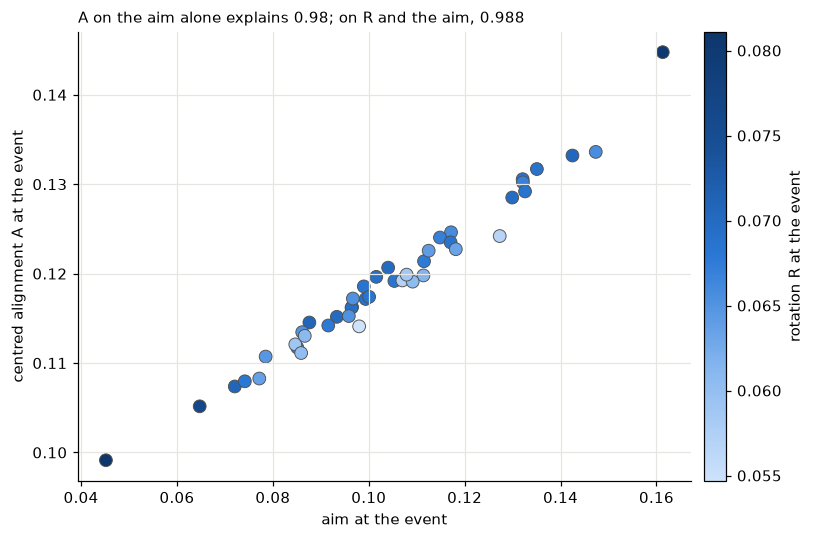

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 5))
sc = ax.scatter(g_ev, A_ev, c=R_ev, cmap=SEQUENTIAL, s=70, edgecolor=L.GRAY, lw=0.6)
fig.colorbar(sc, ax=ax, fraction=0.05, pad=0.02).set_label("rotation R at the event")
ax.set_xlabel("aim at the event")
ax.set_ylabel("centred alignment A at the event")
ax.set_title(f"A on the aim alone explains {fits['the aim alone']['r2']:.2f}; "
             f"on R and the aim, {fits['R and the aim']['r2']:.3f}", loc="left", fontsize=10)
L.tidy_axes(ax)
fig.tight_layout()
print(f"correlation of A and the aim at the event: {np.corrcoef(A_ev, g_ev)[0, 1]:.3f}")

**Figure 3.3. Correlations at the event, and the bootstrap of the plane fit.** Left: the correlation matrix of scale, rotation, alignment and aim over the runs with an event, on a diverging scale from minus one to one. Right: the bootstrap distribution of the share that the plane of L3 explains, with the kill level of 0.5 as a dash-dot line and the estimate as a solid line. If most of the bootstrap mass sat above 0.5, the terms at the event would be close to a plane.

share of bootstrap resamples above 0.5: 0.056


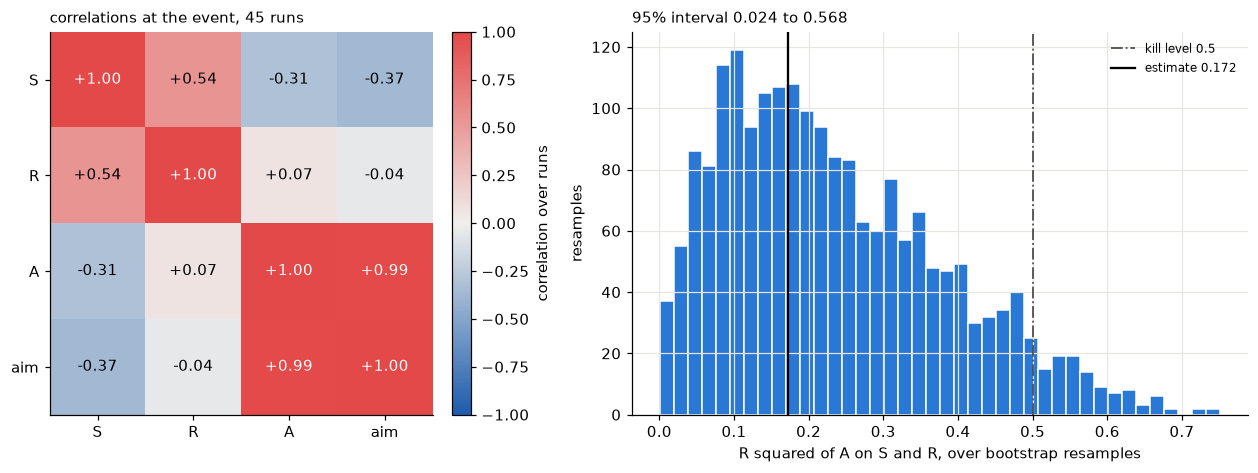

In [13]:
names = ["S", "R", "A", "aim"]
corr = np.corrcoef(np.c_[S_ev, R_ev, A_ev, g_ev].T)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), gridspec_kw=dict(width_ratios=[1, 1.3]))
ax = axes[0]
im = ax.imshow(corr, cmap=DIVERGING, vmin=-1, vmax=1)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{corr[i, j]:+.2f}", ha="center", va="center", fontsize=10,
                color="white" if abs(corr[i, j]) > 0.7 else "black")
ax.set_xticks(range(4)); ax.set_xticklabels(names)
ax.set_yticks(range(4)); ax.set_yticklabels(names)
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label("correlation over runs")
ax.set_title(f"correlations at the event, {len(event)} runs", loc="left", fontsize=10)
ax = axes[1]
ax.hist(plane["boot"], bins=40, color=L.BLUE, edgecolor="white", linewidth=1)
ax.axvline(0.5, color=L.GRAY, lw=1.2, ls="-.", label="kill level 0.5")
ax.axvline(plane["r2"], color="black", lw=1.5, label=f"estimate {plane['r2']:.3f}")
ax.set_xlabel("R squared of A on S and R, over bootstrap resamples")
ax.set_ylabel("resamples")
ax.set_title(f"95% interval {plane['lo']:.3f} to {plane['hi']:.3f}", loc="left", fontsize=10)
ax.legend(fontsize=8)
fig.tight_layout()
print(f"share of bootstrap resamples above 0.5: {np.mean(plane['boot'] > 0.5):.3f}")

## 4. The traced runs (experiment E2)

The traced runs repeat three grid cells at alpha 1 with far more checkpoints: every 250 steps plus 60 log-spaced steps, which start at step 1. The grid runs start at step 500. Before anything else is built on the traces, their histories must agree with the saved grid runs at every checkpoint the two share. The weights follow the same path, so the fields that depend only on the weights must agree exactly. The traces and the grid were both made on this machine with the mixed probe, so the kernel fields should agree exactly too.

The dense runs of `kernel_snapshots.py` have the same weights but the old training-pair probe, so only their training fields can be compared.

**What would count against the traces.** Any nonzero difference in a training field, or a kernel-field difference above float rounding against the grid.

In [14]:
comparison = {}
for alpha, ek in TRACED:
    print(schemas[ek]["run"])
    comparison[ek] = T.compare_with_saved(trace_runs[ek], alpha, ek)

trace_N100_a1_wd0_s0
  grid run ntk_N100_a1_wd0_s0: 61 shared checkpoints. Training fields: largest difference 0.0e+00. Kernel fields: largest difference 0.0e+00 of the field's largest value, in S_t.
  dense run dense_N100_a1_wd0_s0: 121 shared checkpoints. Training fields: largest difference 0.0e+00. Kernel fields not compared, because the saved run uses another probe.
trace_N100_a1_wd0.0003_s0
  grid run ntk_N100_a1_wd0.0003_s0: 61 shared checkpoints. Training fields: largest difference 0.0e+00. Kernel fields: largest difference 0.0e+00 of the field's largest value, in S_t.
  dense run dense_N100_a1_wd0.0003_s0: 121 shared checkpoints. Training fields: largest difference 0.0e+00. Kernel fields not compared, because the saved run uses another probe.
trace_N100_a1_wd0.001_s0
  grid run ntk_N100_a1_wd0.001_s0: 61 shared checkpoints. Training fields: largest difference 0.0e+00. Kernel fields: largest difference 0.0e+00 of the field's largest value, in S_t.
  dense run dense_N100_a1_wd0.0

**Figure 4.1. The four timing variables on the traced runs, with the grid on top.** Each panel is one variable: scale, rotation, alignment and aim. The lines are the traced runs, and the dots are the grid runs at the same cells, every 2,000 steps so that the lines stay visible. The dotted vertical lines are the generalisation events. A dot off its line would count against the traces.

                         run   step       S       R       A     aim test acc
        trace_N100_a1_wd0_s0      1  -0.001  0.0000  0.0888  0.0019    0.000
        trace_N100_a1_wd0_s0    112   0.008  0.0007  0.0888  0.0004    0.000
        trace_N100_a1_wd0_s0   1000   0.187  0.0133  0.0942  0.0409    0.000
        trace_N100_a1_wd0_s0   5000   1.038  0.0468  0.1094  0.0821    0.094
        trace_N100_a1_wd0_s0  10000   1.359  0.0593  0.1114  0.0823    0.736
        trace_N100_a1_wd0_s0  20000   1.541  0.0658  0.1103  0.0768    1.000
        trace_N100_a1_wd0_s0  30000   1.621  0.0704  0.1086  0.0709    1.000
   trace_N100_a1_wd0.0003_s0      1  -0.001  0.0000  0.0888  0.0019    0.000
   trace_N100_a1_wd0.0003_s0    112  -0.049  0.0007  0.0887 -0.0015    0.000
   trace_N100_a1_wd0.0003_s0   1000  -0.146  0.0139  0.0933  0.0347    0.000
   trace_N100_a1_wd0.0003_s0   5000   0.337  0.0555  0.1197  0.1096    0.283
   trace_N100_a1_wd0.0003_s0  10000   0.667  0.0684  0.1326  0.1377    1.000

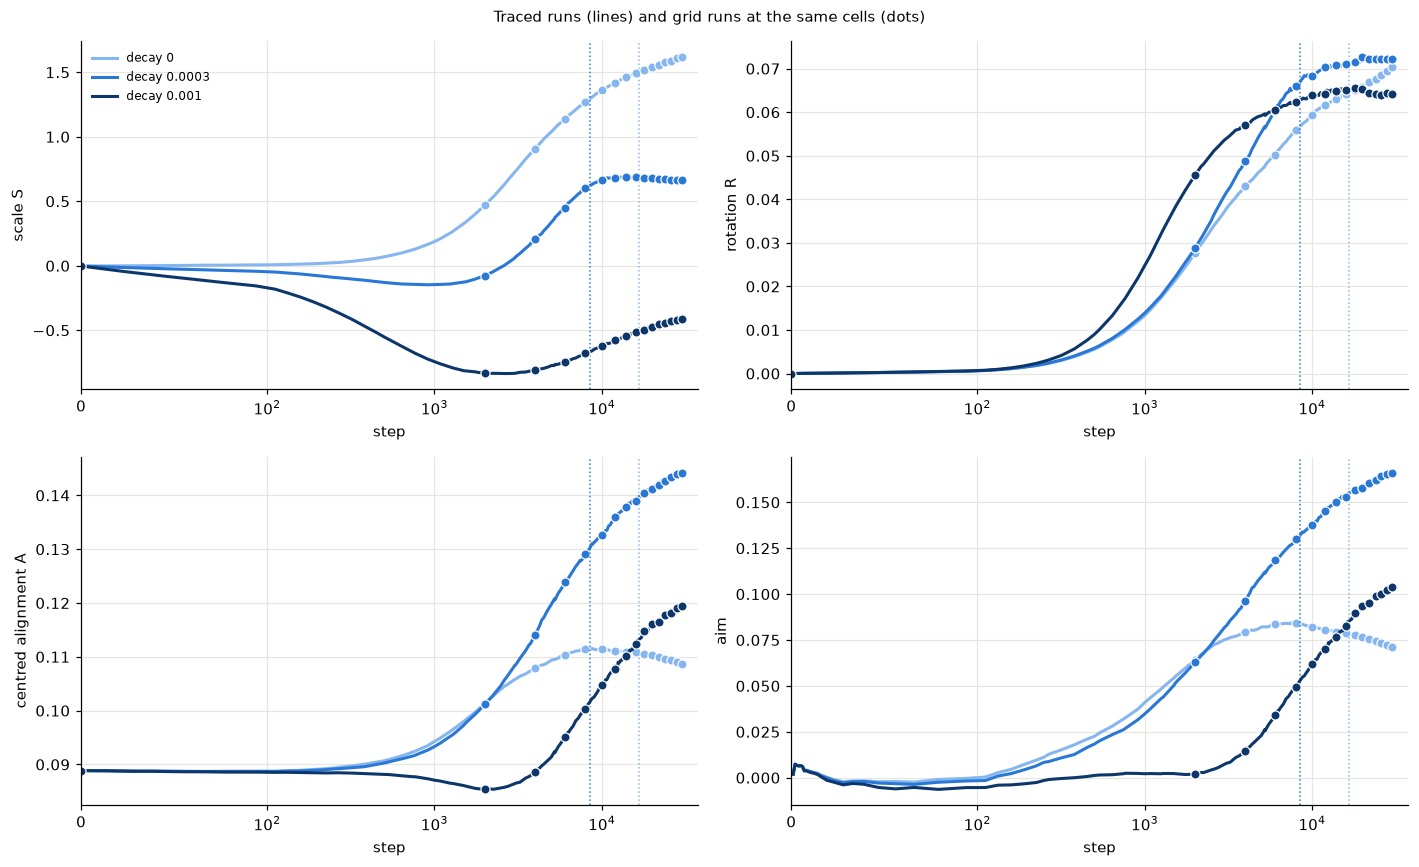

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
panels = [("S", "S_c", "scale S"), ("R", "R_c", "rotation R"), ("A", "A_t", "centred alignment A"), ("gamma", None, "aim")]
for ax, (key, grid_key, ylabel) in zip(axes.ravel(), panels):
    for alpha, ek in TRACED:
        a = traces[ek]
        ax.plot(a["step"], a[key], color=TRACE_COLOURS[ek], label=label(ek))
        g = grid.get(L.cell_name(100, alpha, ek, 0))
        if g is not None:
            h = g["history"]
            steps = np.asarray(h["step"])
            keep = (steps <= 30000) & (steps % 2000 == 0)
            if grid_key is not None:
                values = np.asarray(h[grid_key])
            else:
                values = TD.aim(h["R_c"], h["A_t"], h["A_t"][0])
            ax.plot(steps[keep], values[keep], "o", ms=6, color=TRACE_COLOURS[ek], markeredgecolor="white",
                    markeredgewidth=0.8)
        if events[ek]["t_test"] is not None:
            ax.axvline(events[ek]["t_test"], color=TRACE_COLOURS[ek], lw=1, ls=":")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("step")
    L.log_step_axis(ax)
    L.tidy_axes(ax)
axes[0, 0].legend(fontsize=8)
fig.suptitle("Traced runs (lines) and grid runs at the same cells (dots)", fontsize=10)
fig.tight_layout()
print(f"{'run':>28} {'step':>6} {'S':>7} {'R':>7} {'A':>7} {'aim':>7} {'test acc':>8}")
for _, ek in TRACED:
    a = traces[ek]
    for s in [1, 100, 1000, 5000, 10000, 20000, 30000]:
        i = int(np.searchsorted(a["step"], s))
        print(f"{schemas[ek]['run']:>28} {a['step'][i]:>6} {a['S'][i]:7.3f} {a['R'][i]:7.4f} {a['A'][i]:7.4f} "
              f"{a['gamma'][i]:7.4f} {a['test_acc'][i]:8.3f}")

**Figure 4.2. The first thousand steps, which the grid does not see.** The same four variables on a log step axis from step 1 to step 1,000, with a marker at every checkpoint. The grid has one checkpoint in this range, at step 500. This is the range the report's Kernel metrics section asks the log-spaced grid to cover. The figure shows how early each variable starts to move. If nothing moved before step 500, the log-spaced checkpoints would add nothing.

decay 0, step     1: S -0.00078, R 1.02e-05, A 0.08881, aim +0.0019, train acc 0.155
decay 0, step     2: S -0.00160, R 2.06e-05, A 0.08885, aim +0.0074, train acc 0.168
decay 0, step     5: S -0.00158, R 3.27e-05, A 0.08886, aim +0.0067, train acc 0.202
decay 0, step    10: S -0.00153, R 5.40e-05, A 0.08884, aim +0.0035, train acc 0.233
decay 0, step    19: S -0.00076, R 9.13e-05, A 0.08880, aim +0.0003, train acc 0.313
decay 0, step    47: S +0.00216, R 2.24e-04, A 0.08874, aim -0.0022, train acc 0.464
decay 0, step    94: S +0.00672, R 5.39e-04, A 0.08875, aim -0.0004, train acc 0.555
decay 0, step   250: S +0.02402, R 2.10e-03, A 0.08934, aim +0.0112, train acc 0.718
decay 0, step   500: S +0.06975, R 5.56e-03, A 0.09068, aim +0.0225, train acc 0.857
decay 0, step  1000: S +0.18720, R 1.33e-02, A 0.09425, aim +0.0409, train acc 0.931


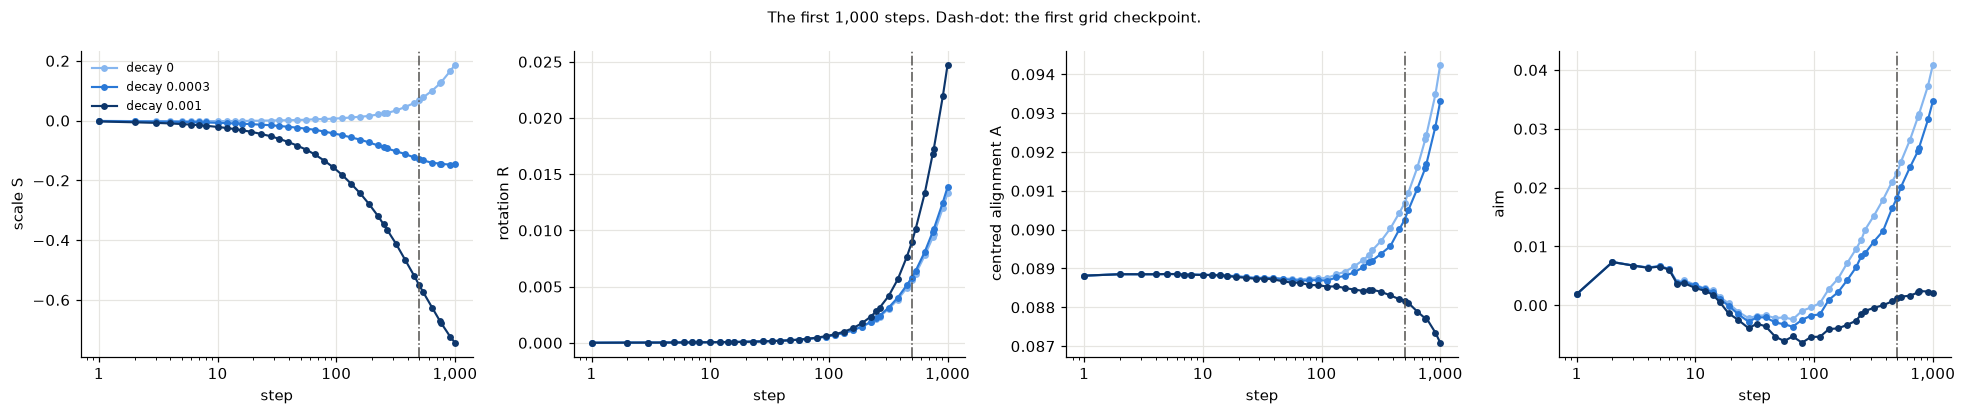

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for ax, (key, _, ylabel) in zip(axes, panels):
    for _, ek in TRACED:
        a = traces[ek]
        keep = (a["step"] >= 1) & (a["step"] <= 1000)
        ax.plot(a["step"][keep], a[key][keep], "o-", ms=3.5, lw=1.4, color=TRACE_COLOURS[ek], label=label(ek))
    ax.axvline(500, color=L.GRAY, lw=1, ls="-.")
    ax.set_xscale("log")
    ax.set_xlabel("step")
    ax.set_ylabel(ylabel)
    L.tidy_axes(ax)
    decades(ax)
axes[0].legend(fontsize=8)
fig.suptitle("The first 1,000 steps. Dash-dot: the first grid checkpoint.", fontsize=10)
fig.tight_layout()
a = traces[0.0]
for s in [1, 2, 5, 10, 21, 50, 100, 245, 500, 1000]:
    i = int(np.argmin(np.abs(a["step"] - s)))
    print(f"decay 0, step {a['step'][i]:>5}: S {a['S'][i]:+.5f}, R {a['R'][i]:.2e}, A {a['A'][i]:.5f}, aim {a['gamma'][i]:+.4f}, "
          f"train acc {a['train_acc'][i]:.3f}")

**The E1 fits on the traces.** The same three shares as Section 2, now on the traced runs, next to the grid run of the same cell cut at step 30,000. The traced runs have the early log-spaced checkpoints, so the two can differ even though the paths are the same. A large difference would mean that the grid's coarse checkpoints change the answer to L2.

In [17]:
def cut(run, last):
    # A copy of a run with the history kept up to a step.
    h = run["history"]
    keep = [i for i, s in enumerate(h["step"]) if s <= last]
    return dict(config=run["config"], history={k: [v[i] for i in keep] for k, v in h.items()})

trace_shares = {r["name"]: r for r in TD.along_run({schemas[ek]["run"]: trace_runs[ek] for _, ek in TRACED})}
grid_shares = {r["name"]: r for r in TD.along_run({L.cell_name(100, 1.0, ek, 0): cut(grid[L.cell_name(100, 1.0, ek, 0)], 30000)
                                                 for _, ek in TRACED})}
print(f"{'cell':>22} {'source':>6} {'checkpoints':>11} {'S on R':>7} {'A on R':>7} {'A on sqrt R':>11}")
for alpha, ek in TRACED:
    for source, rows_, name, run in [("trace", trace_shares, schemas[ek]["run"], trace_runs[ek]),
                                     ("grid", grid_shares, L.cell_name(100, 1.0, ek, 0), cut(grid[L.cell_name(100, 1.0, ek, 0)], 30000))]:
        r = rows_[name]
        print(f"{L.cell_name(100, alpha, ek, 0):>22} {source:>6} {len(run['history']['step']):>11} {r['S_t on R_t']:7.3f} "
              f"{r['A_t on R_t']:7.3f} {r['A_t on sqrt(R_t)']:11.3f}")

                  cell source checkpoints  S on R  A on R A on sqrt R
    ntk_N100_a1_wd0_s0  trace         175   0.995   0.929       0.960
    ntk_N100_a1_wd0_s0   grid          61   0.994   0.762       0.856
ntk_N100_a1_wd0.0003_s0  trace         175   0.904   0.964       0.887
ntk_N100_a1_wd0.0003_s0   grid          61   0.915   0.932       0.816
ntk_N100_a1_wd0.001_s0  trace         175   0.360   0.523       0.437
ntk_N100_a1_wd0.001_s0   grid          61   0.000   0.392       0.275


**Figure 4.3. Scale against rotation on the traced runs, coloured by step.** Each panel is one traced run. The colour of each checkpoint runs from light at step 1 to dark at step 30,000 on a log scale, so the early log-spaced checkpoints are visible. A straight line from light to dark would mean scale and rotation moved in lockstep for the whole run.

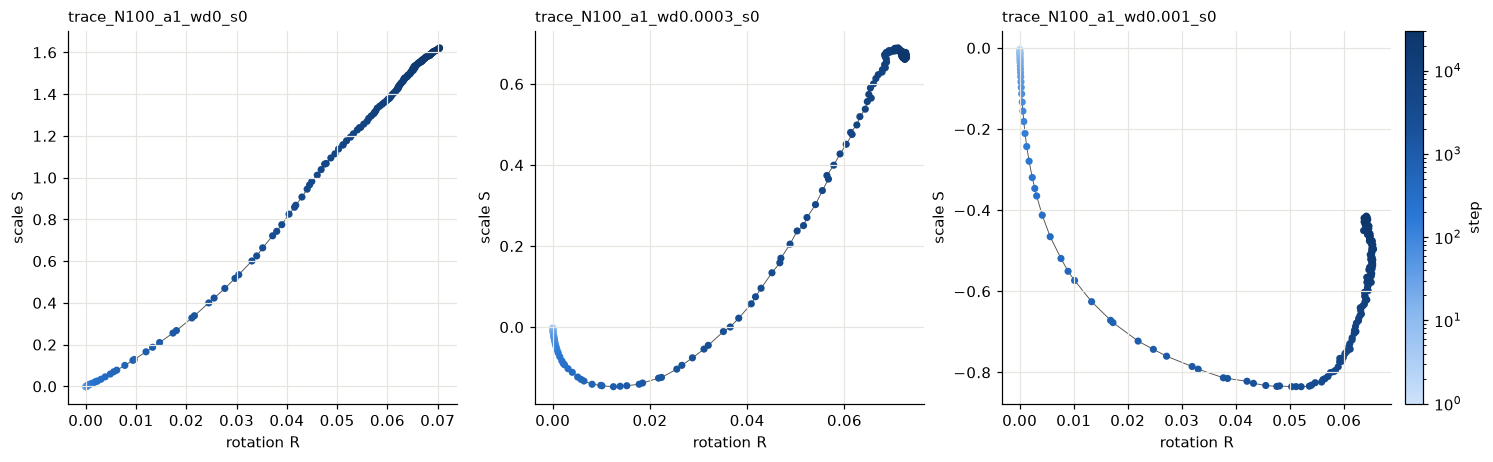

In [18]:
from matplotlib.colors import LogNorm
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for ax, (_, ek) in zip(axes, TRACED):
    a = traces[ek]
    keep = a["step"] >= 1
    sc = ax.scatter(a["R"][keep], a["S"][keep], c=a["step"][keep], cmap=SEQUENTIAL, norm=LogNorm(1, 30000), s=22,
                    edgecolor="none")
    ax.plot(a["R"], a["S"], color=L.GRAY, lw=0.6, zorder=0)
    ax.set_xlabel("rotation R")
    ax.set_ylabel("scale S")
    ax.set_title(schemas[ek]["run"], loc="left", fontsize=10)
    L.tidy_axes(ax)
fig.colorbar(sc, ax=axes, fraction=0.02, pad=0.01).set_label("step")

**Figure 4.4. The two parts of the probe.** The report asks for every metric on the training part and on the test part of the probe as well as pooled. The probe has 203 training pairs and 53 test pairs. Each column is one traced run. The top row shows the alignment and the bottom row the rotation, for the training part in blue, the test part in orange, and the pooled probe as a dashed aqua line. Each part is centred on its own. If the test part looked like the training part, the split would add nothing. Kumar et al. (2024) evaluate their alignment on the test set (Section 5, arXiv v3), so the test part is the one to compare with their uncentred number.

                         run      part     A_0   A end   R end   S end  A_u end
        trace_N100_a1_wd0_s0    pooled  0.0888  0.1086  0.0704   1.621   0.2322
        trace_N100_a1_wd0_s0  training  0.1222  0.1440  0.0670   1.615   0.2540
        trace_N100_a1_wd0_s0      test  0.3903  0.4081  0.0389   1.649   0.4331
   trace_N100_a1_wd0.0003_s0    pooled  0.0888  0.1441  0.0723   0.665   0.2525
   trace_N100_a1_wd0.0003_s0  training  0.1222  0.1800  0.0708   0.670   0.2756
   trace_N100_a1_wd0.0003_s0      test  0.3903  0.4408  0.0368   0.698   0.4643
    trace_N100_a1_wd0.001_s0    pooled  0.0888  0.1195  0.0642  -0.415   0.2384
    trace_N100_a1_wd0.001_s0  training  0.1222  0.1575  0.0627  -0.413   0.2613
    trace_N100_a1_wd0.001_s0      test  0.3903  0.4137  0.0332  -0.409   0.4415


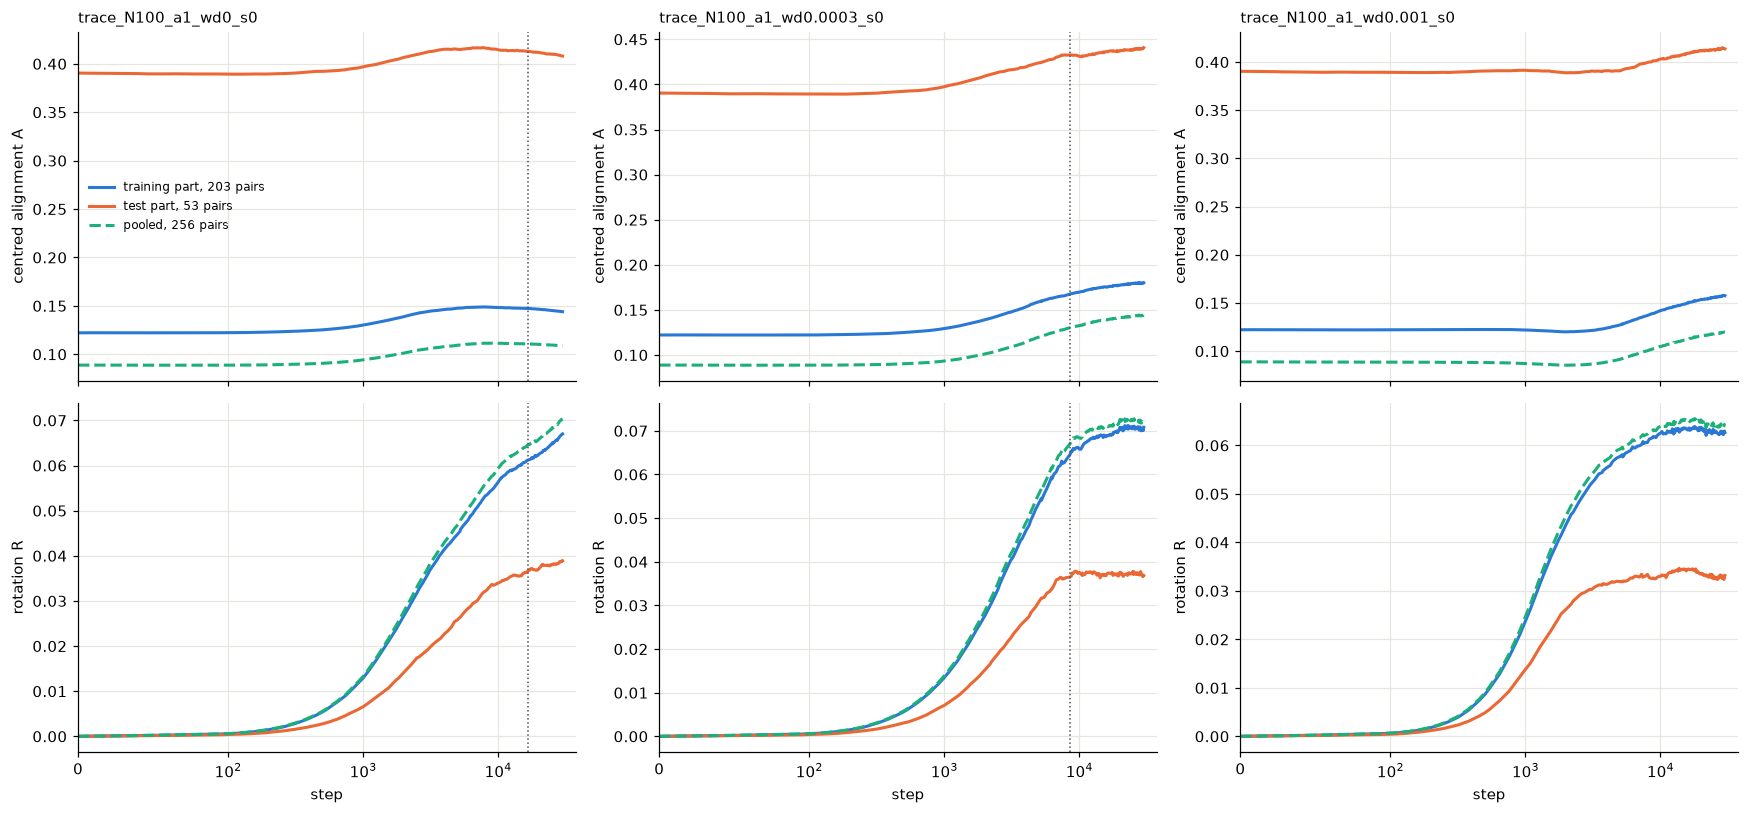

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7.5), sharex=True)
for col, (_, ek) in enumerate(TRACED):
    h = trace_runs[ek]["history"]
    for row, (term, ylabel) in enumerate([("A_t", "centred alignment A"), ("R_c", "rotation R")]):
        ax = axes[row, col]
        ax.plot(h["step"], h[f"{term}_train"], color=L.BLUE, label="training part, 203 pairs")
        ax.plot(h["step"], h[f"{term}_test"], color=L.ORANGE, label="test part, 53 pairs")
        ax.plot(h["step"], h[term], color=L.AQUA, ls="--", label="pooled, 256 pairs")
        if events[ek]["t_test"] is not None:
            ax.axvline(events[ek]["t_test"], color=L.GRAY, lw=1, ls=":")
        ax.set_ylabel(ylabel)
        L.log_step_axis(ax)
        L.tidy_axes(ax)
        if row == 0:
            ax.set_title(schemas[ek]["run"], loc="left", fontsize=10)
        else:
            ax.set_xlabel("step")
axes[0, 0].legend(fontsize=8)
fig.tight_layout()
print(f"{'run':>28} {'part':>9} {'A_0':>7} {'A end':>7} {'R end':>7} {'S end':>7} {'A_u end':>8}")
for _, ek in TRACED:
    h = trace_runs[ek]["history"]
    for part, suffix in [("pooled", ""), ("training", "_train"), ("test", "_test")]:
        print(f"{schemas[ek]['run']:>28} {part:>9} {h['A_t' + suffix][0]:7.4f} {h['A_t' + suffix][-1]:7.4f} "
              f"{h['R_c' + suffix][-1]:7.4f} {h['S_c' + suffix][-1]:7.3f} {h['A_u' + suffix][-1]:8.4f}")

## 5. Where the turn goes (experiment E3)

**Claim L4.** Does the kernel turn inside the plane spanned by its start $k_0$ and the target? If it did, the aim would be one and alignment would be a fixed function of rotation.

**The split.** At each checkpoint the change of the unit kernel $d_t = k_t - k_0$ is split into three orthogonal parts: along $k_0$, along $g_\perp$, and a residual orthogonal to both. The shares of $\lVert d_t\rVert^2$ in the three parts sum to one. They have closed forms, which the schema checks: $R_t/2$, $\gamma_t^2(1 - R_t/2)$ and $(1 - \gamma_t^2)(1 - R_t/2)$.

**Expectation, from the plan.** With an aim near 0.1, the residual share should stay above 0.9 throughout. A residual share falling well below 0.9 would mean the kernel turns mostly towards the target, and L4 would hold.

**Then, what the residual is.** The residual is a symmetric matrix on the probe points. Its leading eigenvectors are functions on the probe pairs $(a, b)$. Each is projected by least squares onto four subspaces: the functions of $(a + b) \bmod p$, of $(a - b) \bmod p$, of $a$ alone and of $b$ alone. The labels live in the sum subspace, which is why the target does not see the other directions. The Fourier structure of the generalising solution, from Nanda et al. (2023), is what motivates these four subspaces.

In [20]:
print(f"{'run':>28} {'share':>15} {'min':>7} {'median':>7} {'max':>7} {'at event':>8}")
for _, ek in TRACED:
    a = traces[ek]
    t = events[ek]["t_test"]
    i_ev = int(np.where(a["step"] <= t)[0][-1]) if t is not None else None
    for share in ["share_k0", "share_gperp", "share_residual"]:
        v = a[share][1:]
        at = f"{a[share][i_ev]:8.4f}" if i_ev is not None else "       -"
        print(f"{schemas[ek]['run']:>28} {share:>15} {v.min():7.4f} {np.median(v):7.4f} {v.max():7.4f} {at}")

                         run           share     min  median     max at event
        trace_N100_a1_wd0_s0        share_k0  0.0000  0.0296  0.0352   0.0323
        trace_N100_a1_wd0_s0     share_gperp  0.0000  0.0056  0.0069   0.0060
        trace_N100_a1_wd0_s0  share_residual  0.9600  0.9638  1.0000   0.9617
   trace_N100_a1_wd0.0003_s0        share_k0  0.0000  0.0343  0.0364   0.0335
   trace_N100_a1_wd0.0003_s0     share_gperp  0.0000  0.0182  0.0266   0.0169
   trace_N100_a1_wd0.0003_s0  share_residual  0.9371  0.9476  1.0000   0.9497
    trace_N100_a1_wd0.001_s0        share_k0  0.0000  0.0319  0.0327        -
    trace_N100_a1_wd0.001_s0     share_gperp  0.0000  0.0036  0.0105        -
    trace_N100_a1_wd0.001_s0  share_residual  0.9574  0.9644  1.0000        -


**Figure 5.1. The three shares of the kernel change.** One column per traced run. The top row shows the residual share on a linear axis zoomed near one, with the expected floor of 0.9 as a dash-dot line. The bottom row shows the two small shares on a log axis: blue along the start, orange dashed along the target direction. A residual line below 0.9 would count against the expectation.

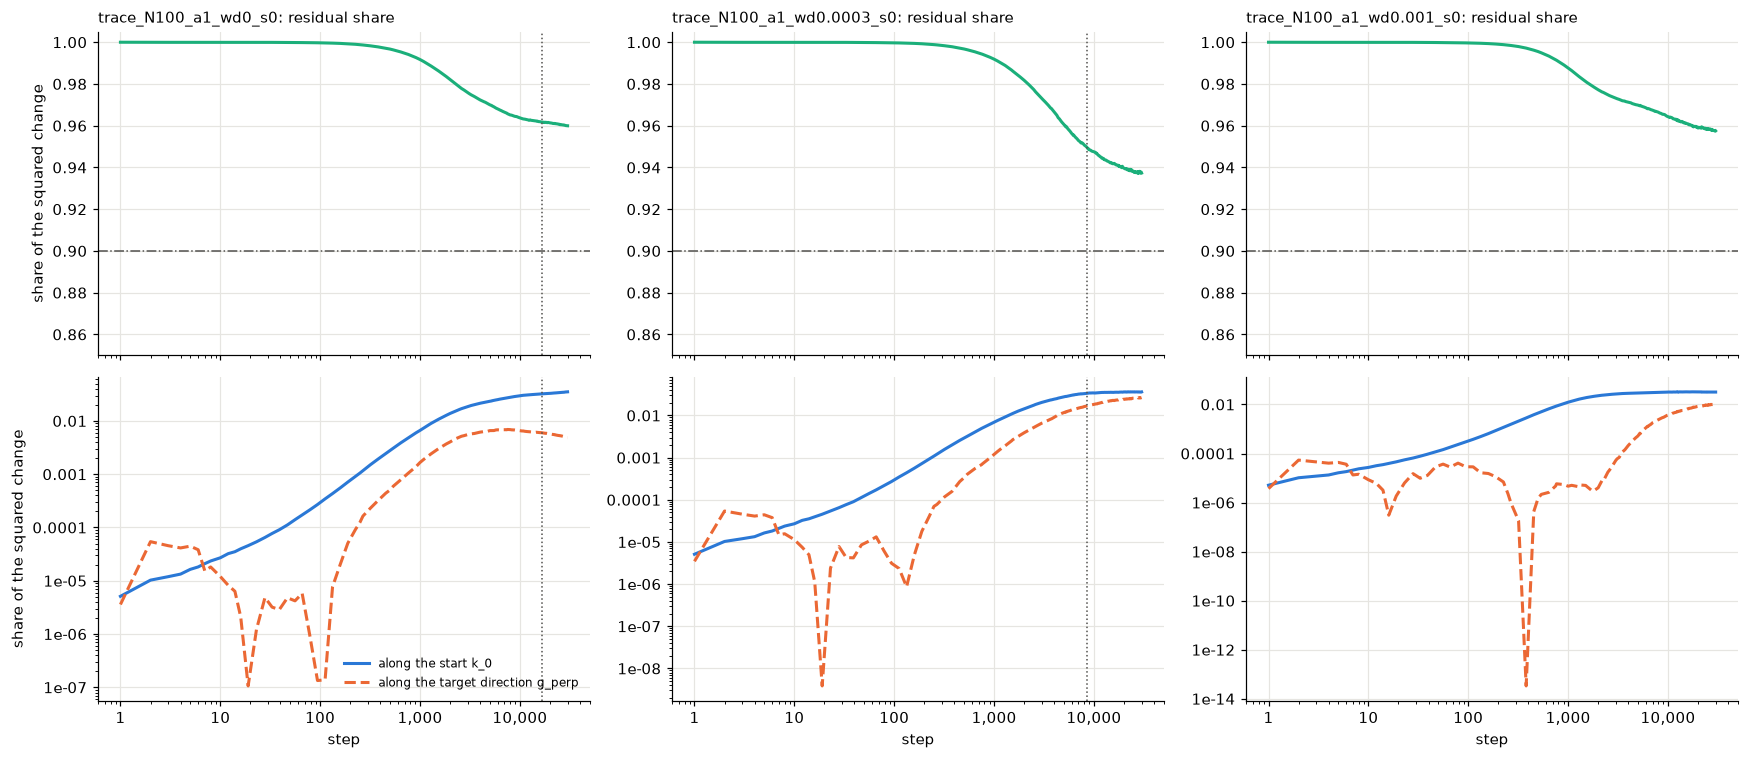

In [21]:
share_style = [("share_k0", L.BLUE, "-", "along the start k_0"), ("share_gperp", L.ORANGE, "--", "along the target direction g_perp"),
               ("share_residual", L.AQUA, "-", "residual, orthogonal to both")]
fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=True)
for col, (_, ek) in enumerate(TRACED):
    a = traces[ek]
    steps = a["step"][1:]
    ax = axes[0, col]
    ax.plot(steps, a["share_residual"][1:], color=L.AQUA)
    ax.axhline(0.9, color=L.GRAY, lw=1, ls="-.")
    ax.set_ylim(0.85, 1.005)
    ax.set_title(f"{schemas[ek]['run']}: residual share", loc="left", fontsize=10)
    ax = axes[1, col]
    ax.plot(steps, a["share_k0"][1:], color=L.BLUE, label="along the start k_0")
    ax.plot(steps, a["share_gperp"][1:], color=L.ORANGE, ls="--", label="along the target direction g_perp")
    ax.set_yscale("log")
    ax.set_xlabel("step")
    for ax in axes[:, col]:
        if events[ek]["t_test"] is not None:
            ax.axvline(events[ek]["t_test"], color=L.GRAY, lw=1, ls=":")
        ax.set_xscale("log")
        L.tidy_axes(ax)
        decades(ax)
    decades(axes[1, col], "y")
axes[0, 0].set_ylabel("share of the squared change")
axes[1, 0].set_ylabel("share of the squared change")
axes[1, 0].legend(fontsize=8, loc="lower right")
fig.tight_layout()

**The leading eigenvectors of the residual.** For every checkpoint after step 0, the residual matrix is rebuilt from the saved kernel with `Tracer.split`. Its four eigenvectors of largest absolute eigenvalue are projected onto the four subspaces. The table gives the energy shares of the leading one at a few steps. The shares need not sum to one, because the subspaces are not orthogonal on a subset of the pairs. A random unit vector would put about $22/255 \approx 0.086$ of its energy in each subspace, so values well above that are structure.

In [22]:
def residual_energy(ek, top=4):
    # Energy shares (sum, difference, a, b) of the top eigenvectors of the residual, by absolute eigenvalue.
    tracer, a = tracers[ek], traces[ek]
    out = np.full((len(a["step"]), top, 4), np.nan)
    eig = np.full((len(a["step"]), top), np.nan)
    for t in range(1, len(a["step"])):
        residual = tracer.split(a["K"][t])["residual"]
        w, U = np.linalg.eigh(residual)
        order = np.argsort(-np.abs(w))[:top]
        out[t] = np.stack([np.sum((Q.T @ U[:, order]) ** 2, axis=0) for Q in tracer.subspace_bases], axis=1)
        eig[t] = w[order]
    return out, eig

res_energy = {ek: residual_energy(ek) for _, ek in TRACED}
print(f"{'run':>28} {'step':>6} {'eigenvalue':>10} {'sum':>6} {'diff':>6} {'a':>6} {'b':>6}   (leading residual eigenvector)")
for _, ek in TRACED:
    a = traces[ek]
    E, eig = res_energy[ek]
    for s in [10, 100, 1000, 5000, 15000, 30000]:
        i = int(np.argmin(np.abs(a["step"] - s)))
        print(f"{schemas[ek]['run']:>28} {a['step'][i]:>6} {eig[i, 0]:+10.2e} " + " ".join(f"{x:6.3f}" for x in E[i, 0]))
print(f"\nchance level for a random unit vector: {22 / 255:.3f} per subspace")

                         run   step eigenvalue    sum   diff      a      b   (leading residual eigenvector)
        trace_N100_a1_wd0_s0     10  +2.49e-03  0.081  0.062  0.286  0.505
        trace_N100_a1_wd0_s0     94  +8.37e-03  0.048  0.026  0.387  0.599
        trace_N100_a1_wd0_s0   1000  -4.70e-02  0.080  0.041  0.375  0.571
        trace_N100_a1_wd0_s0   5000  -9.48e-02  0.061  0.046  0.334  0.607
        trace_N100_a1_wd0_s0  15000  -1.10e-01  0.051  0.040  0.351  0.593
        trace_N100_a1_wd0_s0  30000  -1.17e-01  0.055  0.036  0.321  0.628
   trace_N100_a1_wd0.0003_s0     10  +2.49e-03  0.081  0.062  0.285  0.507
   trace_N100_a1_wd0.0003_s0     94  +8.56e-03  0.045  0.024  0.374  0.630
   trace_N100_a1_wd0.0003_s0   1000  +4.60e-02  0.045  0.056  0.519  0.521
   trace_N100_a1_wd0.0003_s0   5000  +9.70e-02  0.068  0.071  0.591  0.486
   trace_N100_a1_wd0.0003_s0  15000  -1.15e-01  0.049  0.030  0.386  0.561
   trace_N100_a1_wd0.0003_s0  30000  -1.20e-01  0.050  0.030  0.353

**Figure 5.2. What the leading residual direction is made of.** One panel per traced run. Each line is the energy share of the leading residual eigenvector in one subspace: the sum in blue, the difference in orange, $a$ alone in aqua, and $b$ alone in yellow. The dash-dot line is the chance level of 0.086. The plan expected the difference subspace to carry most of the residual, because the kernel change forms an X on the torus with one arm on the sum line and one on the difference line. A leading direction near chance in every subspace would count against that picture.

trace_N100_a1_wd0_s0: mean energy over the last 20 checkpoints, top 4 residual eigenvectors, (sum, difference, a, b):
   eigenvector 0 [0.055 0.037 0.324 0.623]
   eigenvector 1 [0.043 0.095 0.573 0.46 ]
   eigenvector 2 [0.046 0.053 0.545 0.502]
   eigenvector 3 [0.06  0.059 0.488 0.514]
trace_N100_a1_wd0.0003_s0: mean energy over the last 20 checkpoints, top 4 residual eigenvectors, (sum, difference, a, b):
   eigenvector 0 [0.05  0.03  0.361 0.6  ]
   eigenvector 1 [0.032 0.107 0.669 0.375]
   eigenvector 2 [0.047 0.093 0.562 0.504]
   eigenvector 3 [0.042 0.162 0.562 0.455]
trace_N100_a1_wd0.001_s0: mean energy over the last 20 checkpoints, top 4 residual eigenvectors, (sum, difference, a, b):
   eigenvector 0 [0.049 0.061 0.403 0.534]
   eigenvector 1 [0.027 0.091 0.605 0.405]
   eigenvector 2 [0.029 0.09  0.506 0.639]
   eigenvector 3 [0.04  0.087 0.471 0.529]


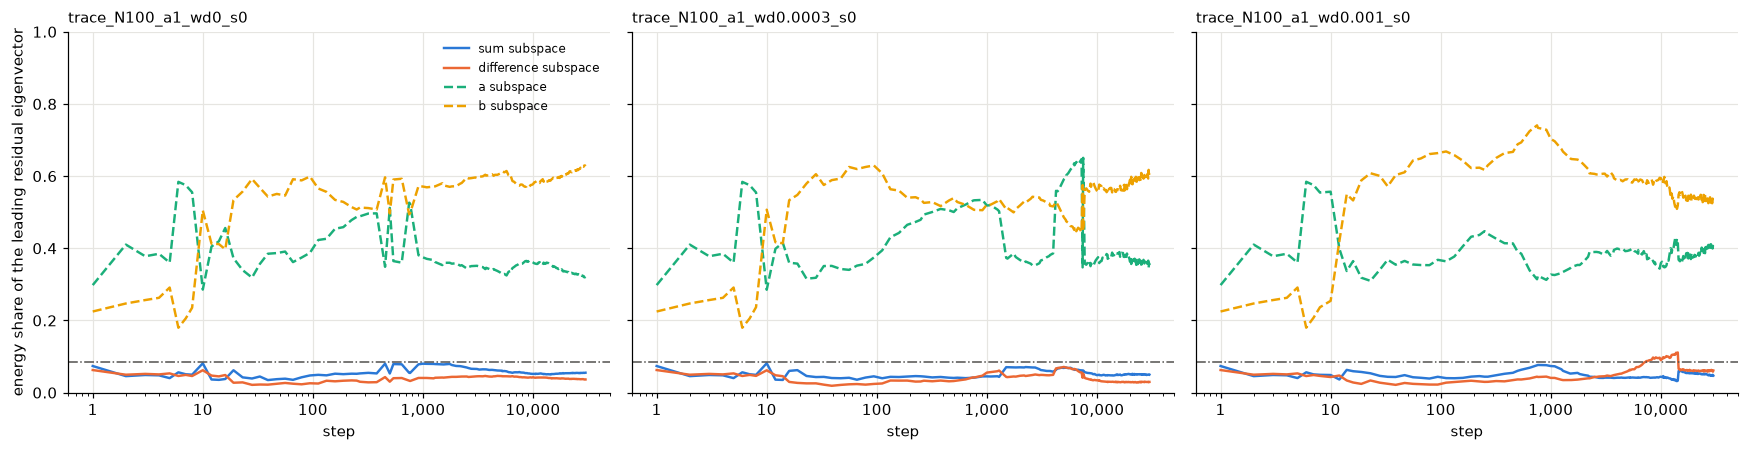

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for ax, (_, ek) in zip(axes, TRACED):
    a = traces[ek]
    E, _ = res_energy[ek]
    for j, space in enumerate(T.SUBSPACES):
        ax.plot(a["step"][1:], E[1:, 0, j], color=SUBSPACE_COLOURS[space], lw=1.6,
                ls="-" if space in ("sum", "difference") else "--", label=f"{space} subspace")
    ax.axhline(22 / 255, color=L.GRAY, lw=1, ls="-.")
    ax.set_xscale("log")
    ax.set_xlabel("step")
    ax.set_ylim(0, 1)
    ax.set_title(schemas[ek]["run"], loc="left", fontsize=10)
    L.tidy_axes(ax)
    decades(ax)
axes[0].set_ylabel("energy share of the leading residual eigenvector")
axes[0].legend(fontsize=8)
fig.tight_layout()
for _, ek in TRACED:
    E, _ = res_energy[ek]
    late = E[-20:, :, :].mean(axis=0)
    print(f"{schemas[ek]['run']}: mean energy over the last 20 checkpoints, top 4 residual eigenvectors, "
          f"(sum, difference, a, b):")
    for j in range(late.shape[0]):
        print("   eigenvector", j, np.round(late[j], 3))

**Where the squared norm of the turn lies.** The leading eigenvector shows only the largest part of the residual. A second measure looks at all of it. For the orthogonal projector $P$ onto one subspace, the share of a matrix $M$ in that subspace block is $\lVert P M P\rVert_F^2 / \lVert M\rVert_F^2$. It is computed for the change $d_t$ and for its residual part, for the four subspaces and for their union, which has dimension 88. What is left outside the union is structure that none of the four subspaces describes.

In [24]:
def block_shares(ek):
    # Shares of the squared norm of the change and of the residual in each subspace block, in the union and outside it.
    tracer, a = tracers[ek], traces[ek]
    P = [Q @ Q.T for Q in tracer.subspace_bases]
    Q_all = T.orthonormal_basis(np.hstack(tracer.subspace_bases))
    P_all = Q_all @ Q_all.T
    out = np.full((len(a["step"]), 2, 6), np.nan)
    for t in range(1, len(a["step"])):
        parts = tracer.split(a["K"][t])
        for m, M in enumerate([parts["change"], parts["residual"]]):
            n2 = np.sum(M ** 2)
            inside = np.sum((P_all @ M @ P_all) ** 2) / n2
            out[t, m] = [*(np.sum((Ps @ M @ Ps) ** 2) / n2 for Ps in P), inside, 1 - inside]
    return out, Q_all.shape[1]

blocks = {}
for _, ek in TRACED:
    blocks[ek], dim = block_shares(ek)
print(f"dimension of the union of the four subspaces: {dim}")
print(f"{'run':>28} {'step':>6} {'matrix':>8} {'sum':>6} {'diff':>6} {'a':>6} {'b':>6} {'union':>6} {'outside':>7}")
for _, ek in TRACED:
    a = traces[ek]
    for s_ in [100, 1000, 5000, 15000, 30000]:
        i = int(np.argmin(np.abs(a["step"] - s_)))
        for m, name in enumerate(["change", "residual"]):
            print(f"{schemas[ek]['run']:>28} {a['step'][i]:>6} {name:>8} " + " ".join(f"{x:6.3f}" for x in blocks[ek][i, m, :5])
                  + f" {blocks[ek][i, m, 5]:7.3f}")

dimension of the union of the four subspaces: 88
                         run   step   matrix    sum   diff      a      b  union outside
        trace_N100_a1_wd0_s0     94   change  0.004  0.005  0.141  0.136  0.566   0.434
        trace_N100_a1_wd0_s0     94 residual  0.004  0.005  0.141  0.137  0.567   0.433
        trace_N100_a1_wd0_s0   1000   change  0.006  0.006  0.187  0.178  0.688   0.312
        trace_N100_a1_wd0_s0   1000 residual  0.004  0.006  0.193  0.178  0.689   0.311
        trace_N100_a1_wd0_s0   5000   change  0.009  0.010  0.180  0.202  0.764   0.236
        trace_N100_a1_wd0_s0   5000 residual  0.004  0.012  0.198  0.206  0.769   0.231
        trace_N100_a1_wd0_s0  15000   change  0.008  0.010  0.188  0.213  0.815   0.185
        trace_N100_a1_wd0_s0  15000 residual  0.004  0.012  0.211  0.221  0.825   0.175
        trace_N100_a1_wd0_s0  30000   change  0.006  0.009  0.197  0.239  0.835   0.165
        trace_N100_a1_wd0_s0  30000 residual  0.003  0.011  0.222  0.24

**Figure 5.3. The residual turn by subspace block.** One column per traced run. The top row shows the share of the residual's squared norm in the four subspace blocks on a log axis: sum in blue, difference in orange, $a$ in aqua dashed, $b$ in yellow dashed. The bottom row shows the share that lies outside all four subspaces. The plan expected the difference block to carry most of the residual. A difference share well above the $a$ and $b$ shares would support that expectation, and a small one counts against it.

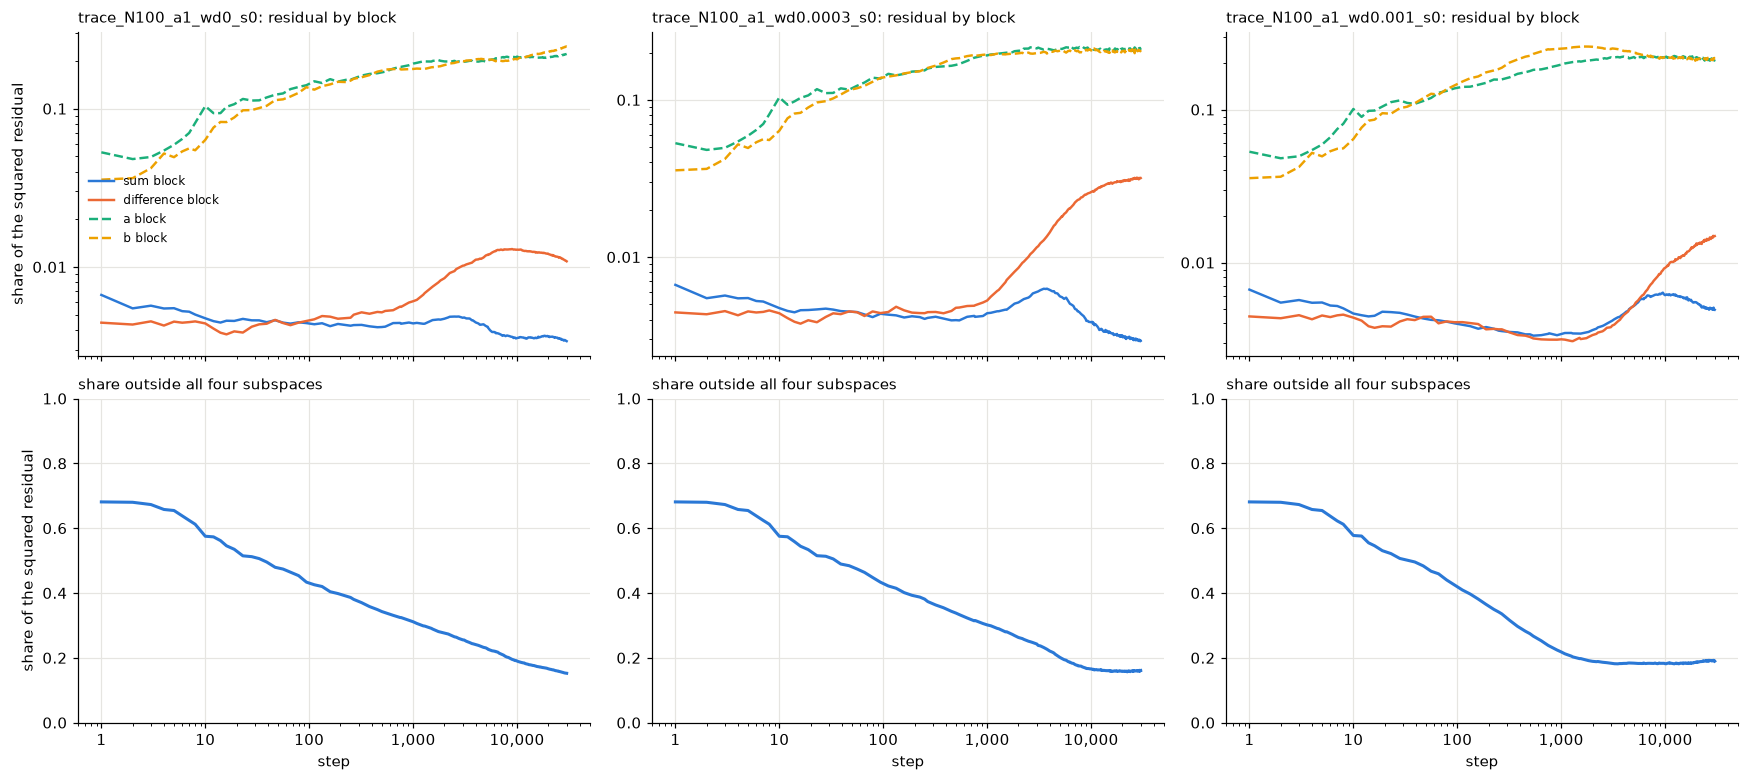

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7.2), sharex=True)
for col, (_, ek) in enumerate(TRACED):
    a = traces[ek]
    steps = a["step"][1:]
    ax = axes[0, col]
    for j, space in enumerate(T.SUBSPACES):
        ax.plot(steps, blocks[ek][1:, 1, j], color=SUBSPACE_COLOURS[space], lw=1.6,
                ls="-" if space in ("sum", "difference") else "--", label=f"{space} block")
    ax.set_yscale("log")
    ax.set_title(f"{schemas[ek]['run']}: residual by block", loc="left", fontsize=10)
    ax = axes[1, col]
    ax.plot(steps, blocks[ek][1:, 1, 5], color=L.BLUE)
    ax.set_ylim(0, 1)
    ax.set_xlabel("step")
    ax.set_title("share outside all four subspaces", loc="left", fontsize=10)
    for ax in axes[:, col]:
        ax.set_xscale("log")
        L.tidy_axes(ax)
        decades(ax)
    decades(axes[0, col], "y")
axes[0, 0].set_ylabel("share of the squared residual")
axes[1, 0].set_ylabel("share of the squared residual")
axes[0, 0].legend(fontsize=8, loc="center left", bbox_to_anchor=(0, 0.45))
fig.tight_layout()

**Figure 5.4. The kernel change and its residual on the torus.** A torus average maps a probe matrix to a $p \times p$ image. Row $i$ holds the offset $a - a'$ and column $j$ the offset $b - b'$, with zero offset in the centre. It averages the matrix over all pairs of probe points with those offsets (`kernels.Torus`). The label kernel is one exactly on the anti-diagonal line where the offsets add to zero. The top row shows the change $d_t$ of the decay 0 run at four steps, and the bottom row shows its residual part. The last column is the target on the torus. Each image has its own symmetric colour scale around zero. Structure along the other diagonal, $a - a' = b - b'$, is structure the target does not see.

  change at step  1000: largest absolute torus value 7.71e-04
  change at step  5000: largest absolute torus value 1.80e-03
  change at step 15000: largest absolute torus value 1.27e-03
  change at step 30000: largest absolute torus value 7.17e-04
residual at step  1000: largest absolute torus value 1.07e-03
residual at step  5000: largest absolute torus value 2.82e-03
residual at step 15000: largest absolute torus value 2.73e-03
residual at step 30000: largest absolute torus value 2.41e-03


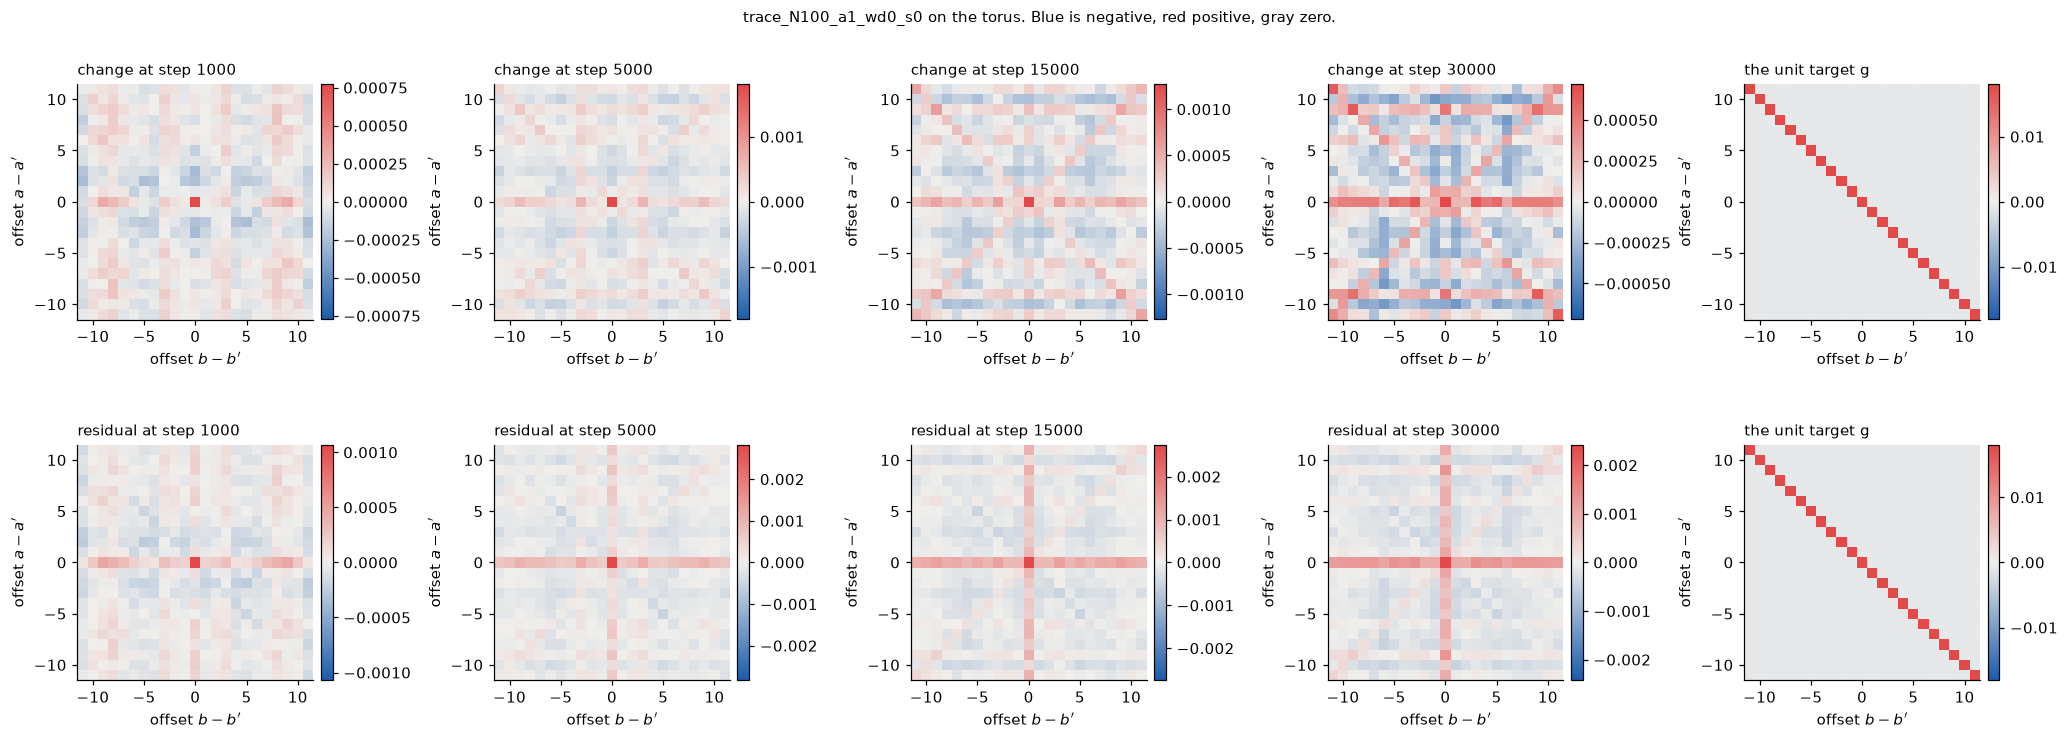

In [26]:
p = 23
ext = [-(p // 2) - 0.5, p // 2 + 0.5, -(p // 2) - 0.5, p // 2 + 0.5]
tracer = tracers[0.0]
target = tracer.torus(tracer.G / tracer.G_norm)
a = traces[0.0]
show = [1000, 5000, 15000, 30000]
fig, axes = plt.subplots(2, 5, figsize=(19, 7))
for row, (key, name) in enumerate([("torus_change", "change"), ("torus_residual", "residual")]):
    for col, s in enumerate(show):
        i = int(np.argmin(np.abs(a["step"] - s)))
        img = a[key][i]
        lim = np.abs(img).max()
        ax = axes[row, col]
        im = ax.imshow(img, origin="lower", extent=ext, cmap=DIVERGING, vmin=-lim, vmax=lim)
        ax.set_title(f"{name} at step {a['step'][i]}", loc="left", fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        print(f"{name:>8} at step {a['step'][i]:>5}: largest absolute torus value {lim:.2e}")
lim = np.abs(target).max()
for row in range(2):
    ax = axes[row, 4]
    im = ax.imshow(target, origin="lower", extent=ext, cmap=DIVERGING, vmin=-lim, vmax=lim)
    ax.set_title("the unit target g", loc="left", fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
for ax in axes.ravel():
    ax.grid(False)
    ax.set_xlabel("offset $b - b'$")
    ax.set_ylabel("offset $a - a'$")
fig.suptitle("trace_N100_a1_wd0_s0 on the torus. Blue is negative, red positive, gray zero.", fontsize=10)
fig.tight_layout()

**Figure 5.5. The residual at the last step for all three traced runs.** Same torus layout, one panel per run, at step 30,000. If decay changed where the kernel turns, the three images would differ in shape and not only in size.

decay 0: mean torus residual on the diagonal a - a' = b - b' +2.65e-04, on the anti-diagonal a - a' = -(b - b') -2.23e-04, largest absolute value 2.41e-03
decay 0.0003: mean torus residual on the diagonal a - a' = b - b' +7.30e-04, on the anti-diagonal a - a' = -(b - b') -3.85e-04, largest absolute value 4.09e-03
decay 0.001: mean torus residual on the diagonal a - a' = b - b' +4.00e-04, on the anti-diagonal a - a' = -(b - b') -2.25e-04, largest absolute value 2.49e-03


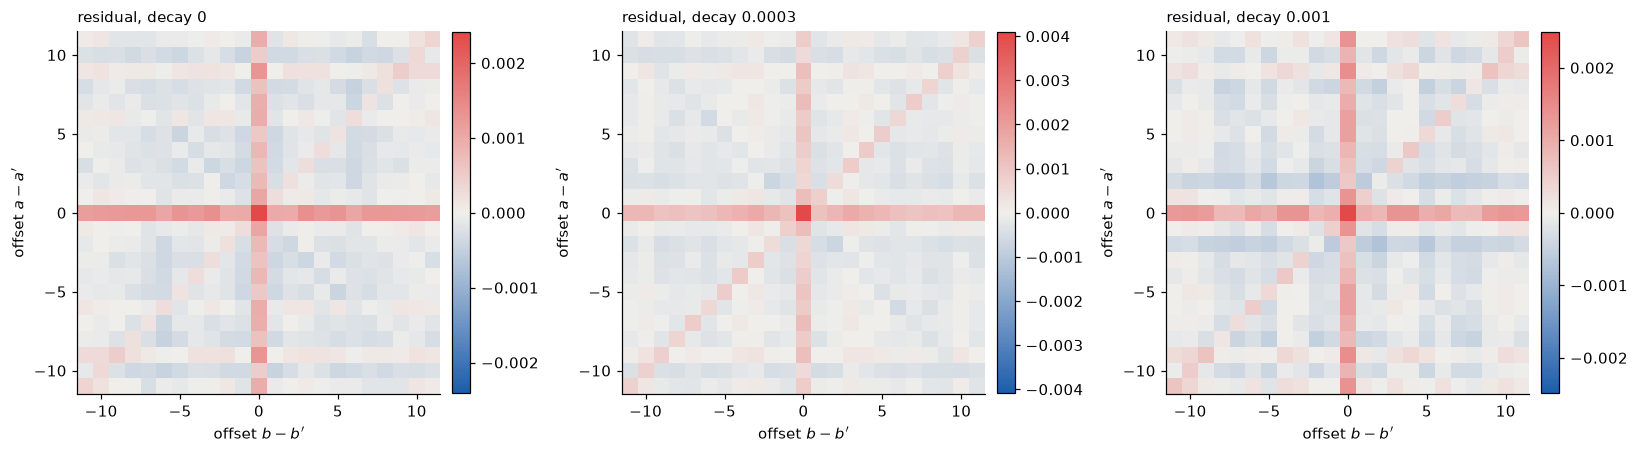

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, (_, ek) in zip(axes, TRACED):
    img = traces[ek]["torus_residual"][-1]
    lim = np.abs(img).max()
    im = ax.imshow(img, origin="lower", extent=ext, cmap=DIVERGING, vmin=-lim, vmax=lim)
    ax.set_title(f"residual, {label(ek)}", loc="left", fontsize=10)
    ax.set_xlabel("offset $b - b'$"); ax.set_ylabel("offset $a - a'$")
    ax.grid(False)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    diag = np.mean([img[i, i] for i in range(p) if i != p // 2])
    anti = np.mean([img[i, p - 1 - i] for i in range(p) if i != p // 2])
    print(f"{label(ek)}: mean torus residual on the diagonal a - a' = b - b' {diag:+.2e}, "
          f"on the anti-diagonal a - a' = -(b - b') {anti:+.2e}, largest absolute value {lim:.2e}")
fig.tight_layout()

## 6. The eigenvectors (experiment E4)

**Conventions, recorded in each schema.** The centred kernel is eigen-decomposed at every checkpoint, largest eigenvalue first. The top $k = 88 = 4(p - 1)$ eigenvectors are kept. Each is matched to one at the previous checkpoint by a linear assignment on the absolute overlaps. An assigned overlap below 0.5 marks a new arrival. Signs are fixed so that each matched vector has a positive inner product with its predecessor.

The plan first chose $k = 32$. The first traces showed that the leading 44 eigenvectors are functions of $a$ alone and $b$ alone, with the largest relative gap in the spectrum right after them. The functions of the sum and the difference then rise out of the bulk to indices 44 to 87. So $k = 88$ holds both blocks.

**What would count against the picture.** New arrivals inside the first block would mean the matching is unstable there. Label angles that do not move would mean the top eigenvectors never find the labels.

In [28]:
print(f"{'run':>28} {'new arrivals':>12} {'in 0-43':>8} {'in 44-65':>9} {'in 66-87':>9} {'median overlap':>14} {'5th pct':>8}")
for _, ek in TRACED:
    a = traces[ek]
    m = a["match_index"][1:]
    t_new, j_new = np.nonzero(m < 0)
    ov = a["overlap_prev"][1:]
    print(f"{schemas[ek]['run']:>28} {len(j_new):>12} {(j_new < 44).sum():>8} {((j_new >= 44) & (j_new < 66)).sum():>9} "
          f"{(j_new >= 66).sum():>9} {np.nanmedian(ov):>14.3f} {np.nanpercentile(ov, 5):>8.3f}")
print()
print(f"{'run':>28} {'step':>6} {'label angles < 45 deg':>21} {'smallest':>8} {'largest':>8} {'traced back to 0':>16} {'median overlap with origin, 0-43':>32}")
for _, ek in TRACED:
    a = traces[ek]
    for s in [0, 1000, 5000, 10000, 20000, 30000]:
        i = int(np.argmin(np.abs(a["step"] - s)))
        ang = np.degrees(a["principal_angles_label"][i])
        print(f"{schemas[ek]['run']:>28} {a['step'][i]:>6} {int((ang < 45).sum()):>21} {ang.min():8.1f} {ang.max():8.1f} "
              f"{int((a['origin_index'][i] >= 0).sum()):>16} {np.nanmedian(a['overlap_zero'][i][:44]):>32.3f}")

                         run new arrivals  in 0-43  in 44-65  in 66-87 median overlap  5th pct
        trace_N100_a1_wd0_s0          112        0         2       110          0.987    0.658
   trace_N100_a1_wd0.0003_s0          199        0         5       194          0.965    0.648
    trace_N100_a1_wd0.001_s0         1106        0        44      1062          0.964    0.453

                         run   step label angles < 45 deg smallest  largest traced back to 0 median overlap with origin, 0-43
        trace_N100_a1_wd0_s0      0                     1     42.3     72.6               88                            1.000
        trace_N100_a1_wd0_s0   1000                     3     38.2     71.7               81                            0.457
        trace_N100_a1_wd0_s0   5000                    12     26.2     68.6               67                            0.290
        trace_N100_a1_wd0_s0  10000                    17     21.1     61.1               64                       

**Figure 6.1. The spectrum.** Left: the top 120 eigenvalues of the centred kernel at step 0, which all three runs share, and at step 30,000 for each run, on a log scale. Right: the relative gap between each eigenvalue and the next. The dash-dot lines mark indices 44 and 88. The claim is that the largest gap sits right after index 43 at both times. A largest gap elsewhere would count against the block structure behind $k = 88$.

                        step 0: largest relative gaps after indices [43, 0, 2] of sizes [0.69, 0.203, 0.115]
          step 30,000, decay 0: largest relative gaps after indices [43, 42, 40] of sizes [0.677, 0.17, 0.096]
     step 30,000, decay 0.0003: largest relative gaps after indices [43, 42, 39] of sizes [0.572, 0.148, 0.099]
      step 30,000, decay 0.001: largest relative gaps after indices [43, 42, 40] of sizes [0.65, 0.141, 0.088]


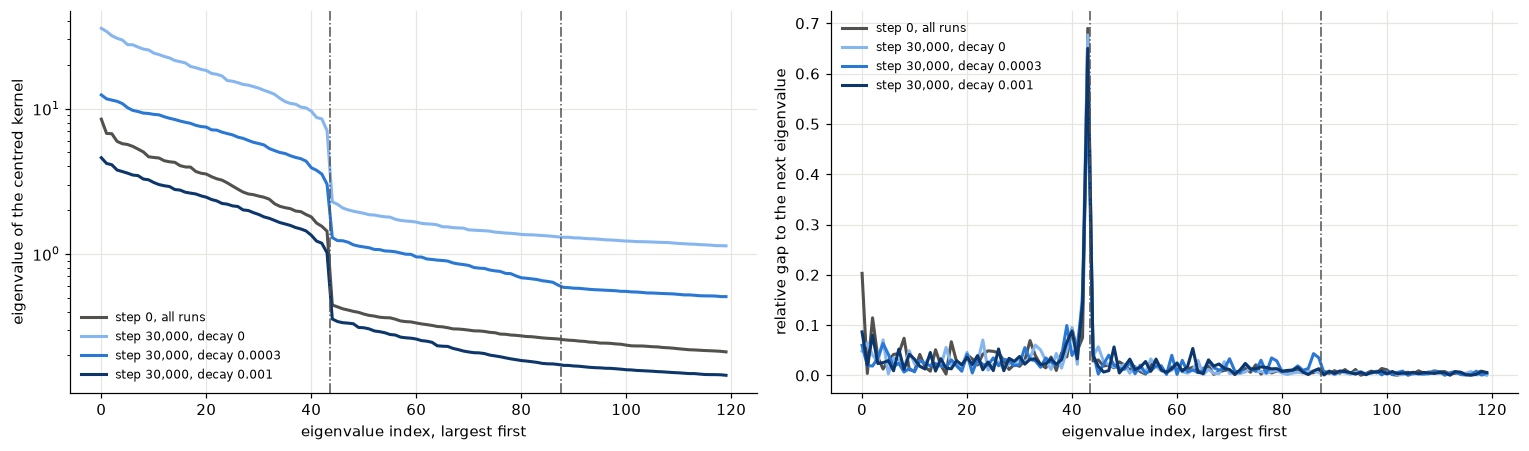

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
idx = np.arange(120)
w0 = traces[0.0]["eigvals"][0][:121]
axes[0].plot(idx, w0[:120], color=L.GRAY, lw=2, label="step 0, all runs")
axes[1].plot(idx, (w0[:-1] - w0[1:]) / w0[:-1], color=L.GRAY, lw=2, label="step 0, all runs")
for _, ek in TRACED:
    w = traces[ek]["eigvals"][-1][:121]
    axes[0].plot(idx, w[:120], color=TRACE_COLOURS[ek], label=f"step 30,000, {label(ek)}")
    axes[1].plot(idx, (w[:-1] - w[1:]) / w[:-1], color=TRACE_COLOURS[ek], label=f"step 30,000, {label(ek)}")
for ax in axes:
    for x in (43.5, 87.5):
        ax.axvline(x, color=L.GRAY, lw=1, ls="-.")
    ax.set_xlabel("eigenvalue index, largest first")
    L.tidy_axes(ax)
    ax.legend(fontsize=8)
axes[0].set_yscale("log"); axes[0].set_ylabel("eigenvalue of the centred kernel")
axes[1].set_ylabel("relative gap to the next eigenvalue")
fig.tight_layout()
for name, w in [("step 0", w0)] + [(f"step 30,000, {label(ek)}", traces[ek]["eigvals"][-1][:121]) for _, ek in TRACED]:
    gaps = (w[:-1] - w[1:]) / w[:-1]
    top = np.argsort(-gaps)[:3]
    print(f"{name:>30}: largest relative gaps after indices {top.tolist()} of sizes {np.round(gaps[top], 3).tolist()}")

**Figure 6.2. How the eigenvalues move.** One panel per traced run, on log axes. Each line is one of the top 88 eigenvalues, by index at each checkpoint. Blue lines are indices 0 to 43, the block of functions of $a$ and of $b$. Orange lines are indices 44 to 87, where the sum and difference functions arrive. The claim is that the two blocks stay apart and that the orange block rises during training. Blocks that mixed would count against it.

trace_N100_a1_wd0_s0: index 0 from 8.47 to 35.75; index 43 from 1.433 to 7.061; index 44 from 0.444 to 2.281; index 87 from 0.259 to 1.309
trace_N100_a1_wd0.0003_s0: index 0 from 8.47 to 12.43; index 43 from 1.433 to 3.021; index 44 from 0.444 to 1.293; index 87 from 0.259 to 0.610
trace_N100_a1_wd0.001_s0: index 0 from 8.47 to 4.59; index 43 from 1.433 to 1.017; index 44 from 0.444 to 0.356; index 87 from 0.259 to 0.173


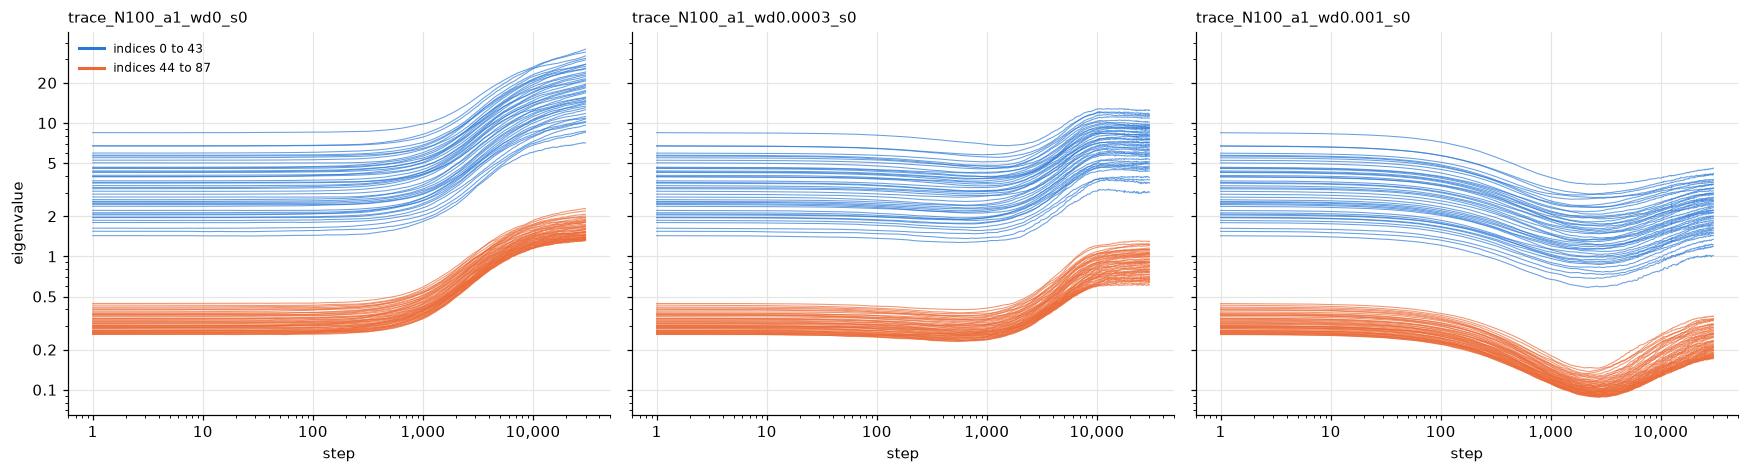

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), sharey=True)
for ax, (_, ek) in zip(axes, TRACED):
    a = traces[ek]
    steps = a["step"][1:]
    for j in range(88):
        ax.plot(steps, a["eigvals"][1:, j], color=L.BLUE if j < 44 else L.ORANGE, lw=0.7, alpha=0.7)
    ax.plot([], [], color=L.BLUE, label="indices 0 to 43")
    ax.plot([], [], color=L.ORANGE, label="indices 44 to 87")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("step")
    ax.set_title(schemas[ek]["run"], loc="left", fontsize=10)
    L.tidy_axes(ax)
    decades(ax)
axes[0].set_ylabel("eigenvalue")
axes[0].legend(fontsize=8)
fig.tight_layout()
for _, ek in TRACED:
    w = traces[ek]["eigvals"]
    print(f"{schemas[ek]['run']}: index 0 from {w[0, 0]:.2f} to {w[-1, 0]:.2f}; index 43 from {w[0, 43]:.3f} to {w[-1, 43]:.3f}; "
          f"index 44 from {w[0, 44]:.3f} to {w[-1, 44]:.3f}; index 87 from {w[0, 87]:.3f} to {w[-1, 87]:.3f}")

**Figure 6.3. Which functions the top eigenvectors are.** Each image has the checkpoint on the horizontal axis and the eigenvector index, 0 at the top, on the vertical axis. The colour is the energy share of that eigenvector in one subspace. The rows are the four subspaces: sum, difference, $a$ and $b$. The columns are the three traced runs. The claim is that indices 0 to 43 are dark in the $a$ and $b$ rows throughout, and that indices 44 to 87 darken in the sum and difference rows during training. Sum and difference energy that stayed at chance, about 0.09, would count against it.

trace_N100_a1_wd0_s0      step 0: mean energy (sum, diff, a, b) in 0-43 [0.052 0.052 0.493 0.492], in 44-87 [0.096 0.091 0.004 0.004]
trace_N100_a1_wd0_s0 step 30,000: mean energy (sum, diff, a, b) in 0-43 [0.056 0.057 0.495 0.495], in 44-87 [0.309 0.245 0.003 0.003]
trace_N100_a1_wd0.0003_s0      step 0: mean energy (sum, diff, a, b) in 0-43 [0.052 0.052 0.493 0.492], in 44-87 [0.096 0.091 0.004 0.004]
trace_N100_a1_wd0.0003_s0 step 30,000: mean energy (sum, diff, a, b) in 0-43 [0.061 0.064 0.495 0.495], in 44-87 [0.408 0.385 0.004 0.004]
trace_N100_a1_wd0.001_s0      step 0: mean energy (sum, diff, a, b) in 0-43 [0.052 0.052 0.493 0.492], in 44-87 [0.096 0.091 0.004 0.004]
trace_N100_a1_wd0.001_s0 step 30,000: mean energy (sum, diff, a, b) in 0-43 [0.058 0.059 0.494 0.495], in 44-87 [0.321 0.28  0.004 0.003]


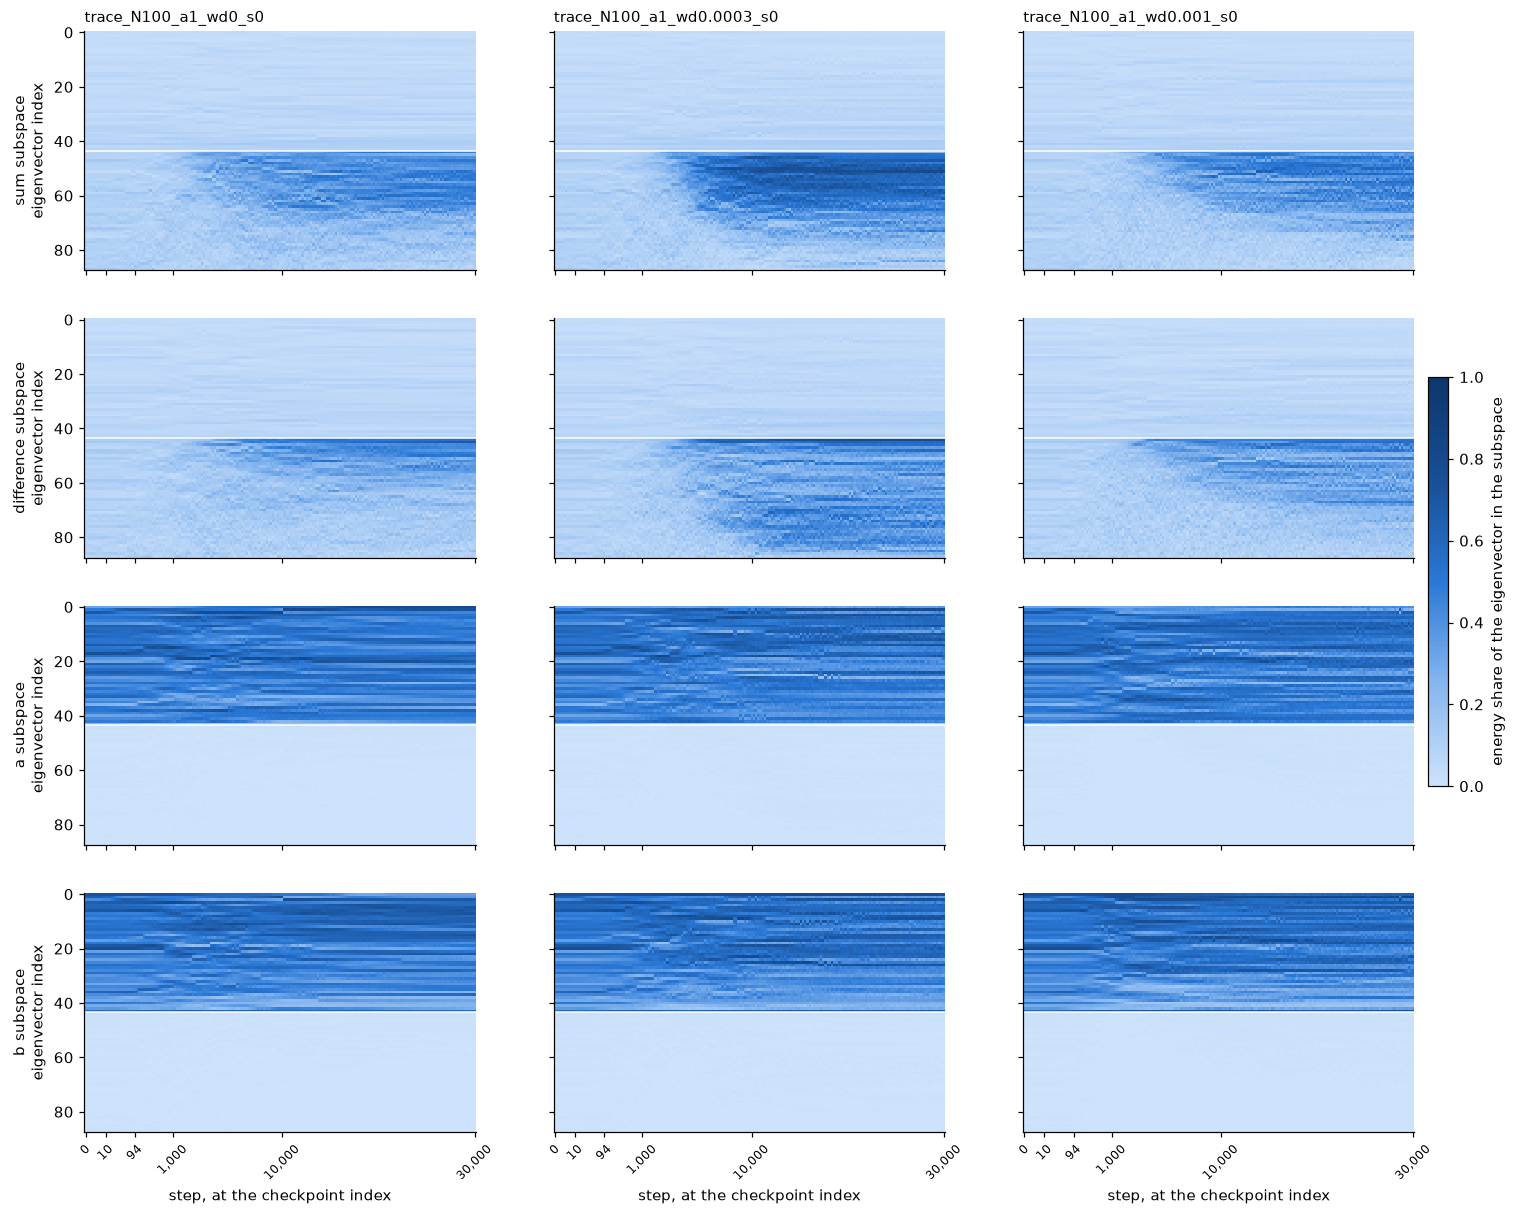

In [31]:
fig, axes = plt.subplots(4, 3, figsize=(16, 13), sharex="col", sharey=True)
for col, (_, ek) in enumerate(TRACED):
    a = traces[ek]
    ticks = [int(np.argmin(np.abs(a["step"] - s))) for s in [0, 10, 100, 1000, 10000, 30000]]
    for row, space in enumerate(T.SUBSPACES):
        ax = axes[row, col]
        im = ax.imshow(a["subspace_energy"][:, :, row].T, aspect="auto", cmap=SEQUENTIAL, vmin=0, vmax=1,
                       interpolation="nearest")
        ax.axhline(43.5, color="white", lw=1)
        ax.grid(False)
        ax.set_xticks(ticks); ax.set_xticklabels([f"{a['step'][t]:,}" for t in ticks], fontsize=8, rotation=45)
        if col == 0:
            ax.set_ylabel(f"{space} subspace\neigenvector index")
        if row == 0:
            ax.set_title(schemas[ek]["run"], loc="left", fontsize=10)
        if row == 3:
            ax.set_xlabel("step, at the checkpoint index")
fig.colorbar(im, ax=axes, fraction=0.015, pad=0.01).set_label("energy share of the eigenvector in the subspace")
for _, ek in TRACED:
    E = traces[ek]["subspace_energy"]
    for t, s in [(0, "step 0"), (-1, "step 30,000")]:
        print(f"{schemas[ek]['run']} {s:>11}: mean energy (sum, diff, a, b) in 0-43 {np.round(E[t, :44].mean(0), 3)}, "
              f"in 44-87 {np.round(E[t, 44:].mean(0), 3)}")

**Figure 6.4. How long each eigenvector keeps its identity.** Top row: the overlap of each matched eigenvector with its predecessor, by checkpoint and index, with new arrivals as orange dots. Bottom row: the median overlap with the step 0 vector that the chain of matches leads back to, for the two blocks. A matching that works gives overlaps near one from one checkpoint to the next. The drift over the whole run is a separate question. A chain can keep high overlaps at every step and still end far from where it started, when neighbouring eigenvalues are close and the vectors mix slowly.

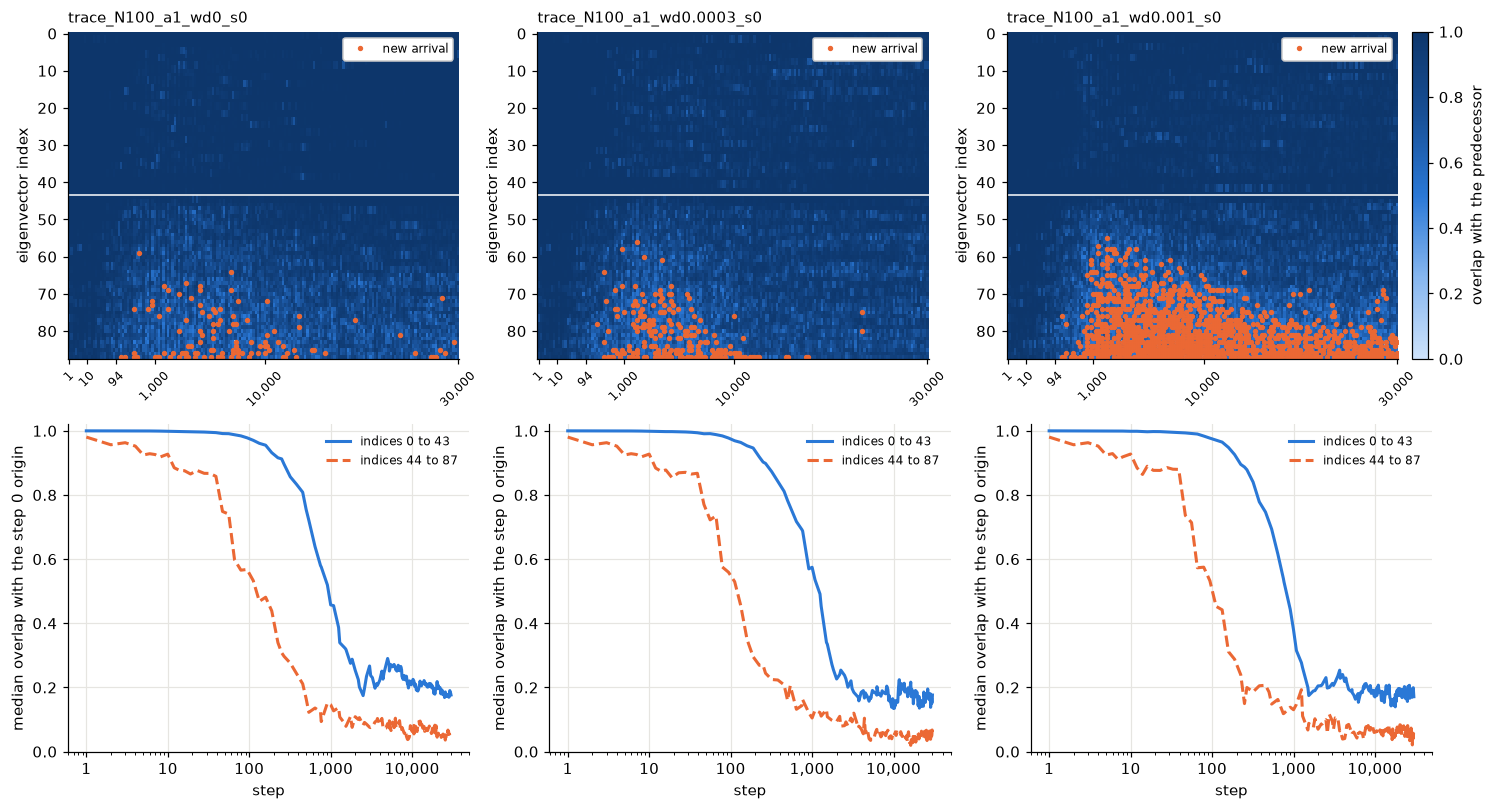

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
for col, (_, ek) in enumerate(TRACED):
    a = traces[ek]
    ax = axes[0, col]
    im = ax.imshow(a["overlap_prev"][1:].T, aspect="auto", cmap=SEQUENTIAL, vmin=0, vmax=1, interpolation="nearest")
    t_new, j_new = np.nonzero(a["match_index"][1:] < 0)
    ax.plot(t_new, j_new, "o", ms=2.5, color=L.ORANGE, label="new arrival")
    ax.axhline(43.5, color="white", lw=1)
    ax.grid(False)
    ticks = [int(np.argmin(np.abs(a["step"][1:] - s))) for s in [1, 10, 100, 1000, 10000, 30000]]
    ax.set_xticks(ticks); ax.set_xticklabels([f"{a['step'][1:][t]:,}" for t in ticks], fontsize=8)
    ax.set_title(schemas[ek]["run"], loc="left", fontsize=10)
    ax.set_ylabel("eigenvector index")
    ax.set_xticklabels([f"{a['step'][1:][t]:,}" for t in ticks], fontsize=8, rotation=45)
    ax.legend(fontsize=8, loc="upper right", frameon=True, facecolor="white", framealpha=1)
    ax = axes[1, col]
    oz = a["overlap_zero"]
    ax.plot(a["step"][1:], np.nanmedian(oz[1:, :44], axis=1), color=L.BLUE, label="indices 0 to 43")
    med_b = [np.nanmedian(r[44:]) if np.isfinite(r[44:]).any() else np.nan for r in oz[1:]]
    ax.plot(a["step"][1:], med_b, color=L.ORANGE, ls="--", label="indices 44 to 87")
    ax.set_xscale("log"); ax.set_ylim(0, 1.02)
    ax.set_xlabel("step"); ax.set_ylabel("median overlap with the step 0 origin")
    ax.legend(fontsize=8)
    L.tidy_axes(ax)
    decades(ax)
fig.colorbar(im, ax=axes[0, :], fraction=0.015, pad=0.01).set_label("overlap with the predecessor")

**Figure 6.5. Principal angles.** Top row: the principal angles between the span of the top 88 eigenvectors and the same span at step 0. The lines are the smallest angle, the median angle and the largest angle. Bottom row: the 22 principal angles between the top 88 span and the label subspace, the column space of $HY$, each as a thin line, with 45 degrees as a dash-dot line. The claim is that the top span keeps most of its step 0 directions while it gains the label directions. Label angles that stayed near their step 0 values would count against it.

trace_N100_a1_wd0_s0: first step with at least 5, 11, 18 and 22 label angles below 45 degrees: {5: 1250, 11: 4000, 18: 11000, 22: None}
trace_N100_a1_wd0.0003_s0: first step with at least 5, 11, 18 and 22 label angles below 45 degrees: {5: 1750, 11: 3250, 18: 5500, 22: 9500}
trace_N100_a1_wd0.001_s0: first step with at least 5, 11, 18 and 22 label angles below 45 degrees: {5: 2000, 11: 5750, 18: 12523, 22: None}


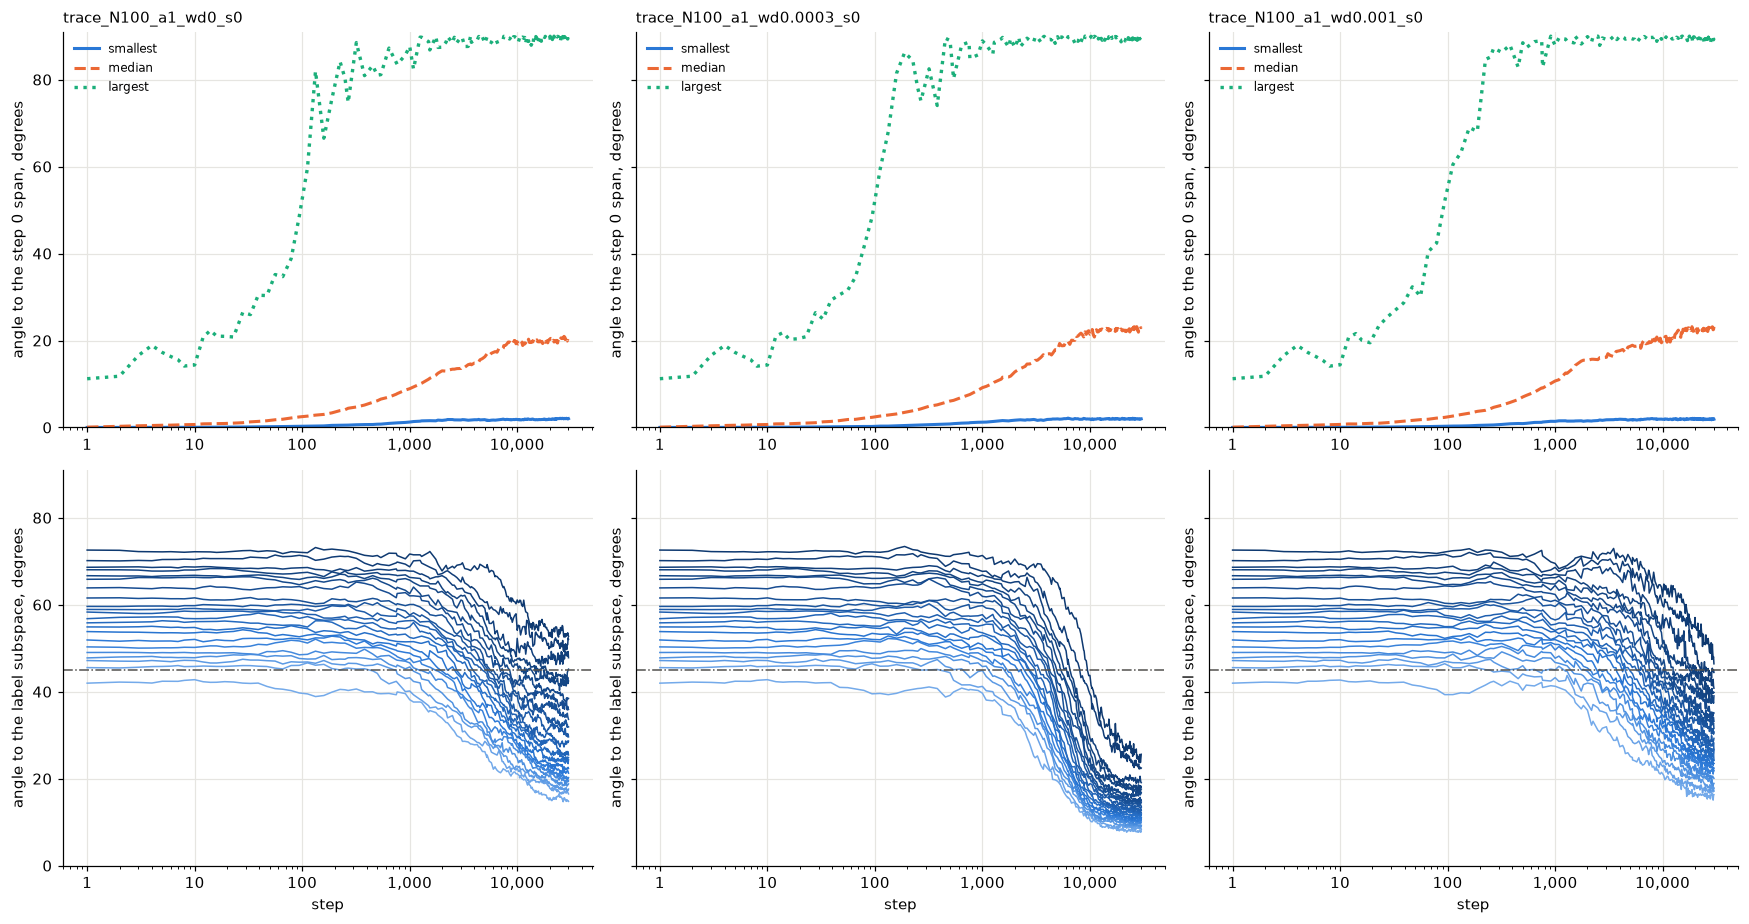

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5), sharey="row")
for col, (_, ek) in enumerate(TRACED):
    a = traces[ek]
    steps = a["step"][1:]
    ang0 = np.degrees(a["principal_angles_zero"][1:])
    ax = axes[0, col]
    ax.plot(steps, ang0[:, 0], color=L.BLUE, label="smallest")
    ax.plot(steps, np.median(ang0, axis=1), color=L.ORANGE, ls="--", label="median")
    ax.plot(steps, ang0[:, -1], color=L.AQUA, ls=":", lw=2.2, label="largest")
    ax.set_xscale("log"); ax.set_ylim(0, 91)
    ax.set_title(schemas[ek]["run"], loc="left", fontsize=10)
    ax.set_ylabel("angle to the step 0 span, degrees")
    ax.legend(fontsize=8)
    L.tidy_axes(ax)
    decades(ax)
    ax = axes[1, col]
    angl = np.degrees(a["principal_angles_label"])
    for j in range(angl.shape[1]):
        ax.plot(a["step"][1:], angl[1:, j], color=SEQUENTIAL(0.3 + 0.7 * j / angl.shape[1]), lw=1)
    ax.axhline(45, color=L.GRAY, lw=1, ls="-.")
    ax.set_xscale("log"); ax.set_ylim(0, 91)
    ax.set_xlabel("step"); ax.set_ylabel("angle to the label subspace, degrees")
    L.tidy_axes(ax)
    decades(ax)
fig.tight_layout()
for _, ek in TRACED:
    a = traces[ek]
    below = (np.degrees(a["principal_angles_label"]) < 45).sum(axis=1)
    first = {n: next((int(a["step"][i]) for i in range(len(below)) if below[i] >= n), None) for n in (5, 11, 18, 22)}
    print(f"{schemas[ek]['run']}: first step with at least 5, 11, 18 and 22 label angles below 45 degrees: {first}")

## 7. A synthetic control (experiment E5)

Every estimator above should give a known answer when the answer is known. Two artificial kernel paths are built from the step 0 kernel of the decay 0 run. No network made them, and the figures in this section are schematic in the sense of `animations/CLAUDE.md`.

- **Pure scale.** $K_t = c_t K_0$ with $c_t$ running from 1 to 5. Expected: $S_t = \log c_t$, a rotation of zero, an aim that is undefined, a residual share that is undefined, and eigenvectors that do not move.
- **Pure rotation towards the target.** The unit kernel moves along the great circle from $k_0$ to the unit target $g$ at a fixed norm, $k(\theta) = \cos\theta\, k_0 + \sin\theta\, g_\perp$. Expected: a scale term of zero, an aim of one, a residual share of zero, and an alignment that reaches one at the end of the path.

Both paths go through the same `Tracer.measure` code that made the traces. Any expected value that the estimators miss by more than rounding would mean a bug.

The control has already found one. The first version of the tracer left the aim undefined only when the change of the unit kernel was exactly zero. On the pure scale path float64 rounding leaves a change of about $10^{-16}$, and the tracer turned that noise into an aim between $-0.02$ and $0.01$. The tracer now treats a change with squared norm below $10^{-24}$ as no change (`ntk_trace.UNMOVED`). In the trained runs the smallest real change, at step 1, has a squared norm near $2 \times 10^{-5}$, so all 43 arrays of the three traces came out identical after the fix.

In [34]:
cfg0 = {**L.DEFAULTS, **T.run_config(1.0, 0.0, 30000)}
K0 = traces[0.0]["K"][0].astype(np.float64)
ref = T.Tracer(cfg0)
ref.measure(0, K0)
k0, g_perp, norm0 = ref.k_0, ref.g_perp, ref.norm_0
theta_max = np.arccos(T.inner(ref.G / ref.G_norm, k0))
n_steps = 41
c = np.linspace(1, 5, n_steps)
theta = np.linspace(0, theta_max, n_steps)
paths = {
    "pure scale": [ci * K0 for ci in c],
    "pure rotation": [norm0 * (np.cos(t) * k0 + np.sin(t) * g_perp) for t in theta],
}
synthetic = {}
for name, path in paths.items():
    tracer = T.Tracer(cfg0)
    rows = [tracer.measure(i, K) for i, K in enumerate(path)]
    synthetic[name] = {key: np.stack([np.asarray(r[key]) for r in rows]) for key in rows[0]}
s, r = synthetic["pure scale"], synthetic["pure rotation"]
print(f"rotation angle from k_0 to the target: {np.degrees(theta_max):.1f} degrees (A_0 = {ref.A_0:.4f})")
print("Pure scale:")
print(f"  largest |S - log c|               {np.abs(s['S'] - np.log(c)).max():.1e}   expected 0")
print(f"  largest |R|                       {np.abs(s['R']).max():.1e}   expected 0")
print(f"  aims that are NaN                 {int(np.isnan(s['gamma']).sum())} of {n_steps}   expected all")
print(f"  residual shares that are NaN      {int(np.isnan(s['share_residual']).sum())} of {n_steps}   expected all")
print(f"  largest |A - A_0|                 {np.abs(s['A'] - ref.A_0).max():.1e}   expected 0")
print(f"  smallest overlap with predecessor {np.nanmin(s['overlap_prev'][1:]):.6f}   expected 1")
print(f"  largest angle to the step 0 span  {np.degrees(s['principal_angles_zero']).max():.1e} degrees   expected 0")
print(f"  new arrivals                      {int((s['match_index'][1:] < 0).sum())}   expected 0")
print("Pure rotation:")
print(f"  largest |S|                       {np.abs(r['S']).max():.1e}   expected 0")
print(f"  aim, smallest and largest         {np.nanmin(r['gamma']):.6f}, {np.nanmax(r['gamma']):.6f}   expected 1")
print(f"  largest residual share            {np.nanmax(r['share_residual']):.1e}   expected 0")
print(f"  largest |R - (1 - cos theta)|     {np.abs(r['R'] - (1 - np.cos(theta))).max():.1e}   expected 0")
print(f"  alignment at the end              {r['A'][-1]:.6f}   expected 1")
print(f"  label angles below 1 degree at the end {int((np.degrees(r['principal_angles_label'][-1]) < 1).sum())} of 22")
print(f"  new arrivals along the path       {int((r['match_index'][1:] < 0).sum())}")
path_shares = TD.along_run({name: dict(config=dict(alpha=1.0, eta_kappa=0.0, seed=0),
                                       history=dict(S_c=v["S"].tolist(), R_c=v["R"].tolist(), A_t=v["A"].tolist()))
                            for name, v in synthetic.items()})
def show(x):
    return "undefined" if np.isnan(x) else f"{x:.3f}"

for row in path_shares:
    print(f"E1 shares on the {row['name']} path: S on R {show(row['S_t on R_t'])}, A on R {show(row['A_t on R_t'])}, "
          f"A on sqrt R {show(row['A_t on sqrt(R_t)'])}. A share is undefined where a series is constant up to rounding.")

rotation angle from k_0 to the target: 84.9 degrees (A_0 = 0.0888)
Pure scale:
  largest |S - log c|               2.2e-16   expected 0
  largest |R|                       2.2e-16   expected 0
  aims that are NaN                 41 of 41   expected all
  residual shares that are NaN      41 of 41   expected all
  largest |A - A_0|                 5.6e-17   expected 0
  smallest overlap with predecessor 1.000000   expected 1
  largest angle to the step 0 span  3.9e-06 degrees   expected 0
  new arrivals                      0   expected 0
Pure rotation:
  largest |S|                       4.4e-16   expected 0
  aim, smallest and largest         1.000000, 1.000000   expected 1
  largest residual share            4.8e-28   expected 0
  largest |R - (1 - cos theta)|     2.2e-16   expected 0
  alignment at the end              1.000000   expected 1
  label angles below 1 degree at the end 22 of 22
  new arrivals along the path       124
E1 shares on the pure scale path: S on R undefined, A 

**Figure 7.1. The estimators on the two synthetic paths.** Top row: pure scale against the scale factor. Bottom row: pure rotation against the angle travelled. The columns are scale, rotation, alignment and aim. The dash-dot lines are the expected values. Any line off its expected value would mean a bug. The aim on the pure scale path is undefined, so that panel is empty.

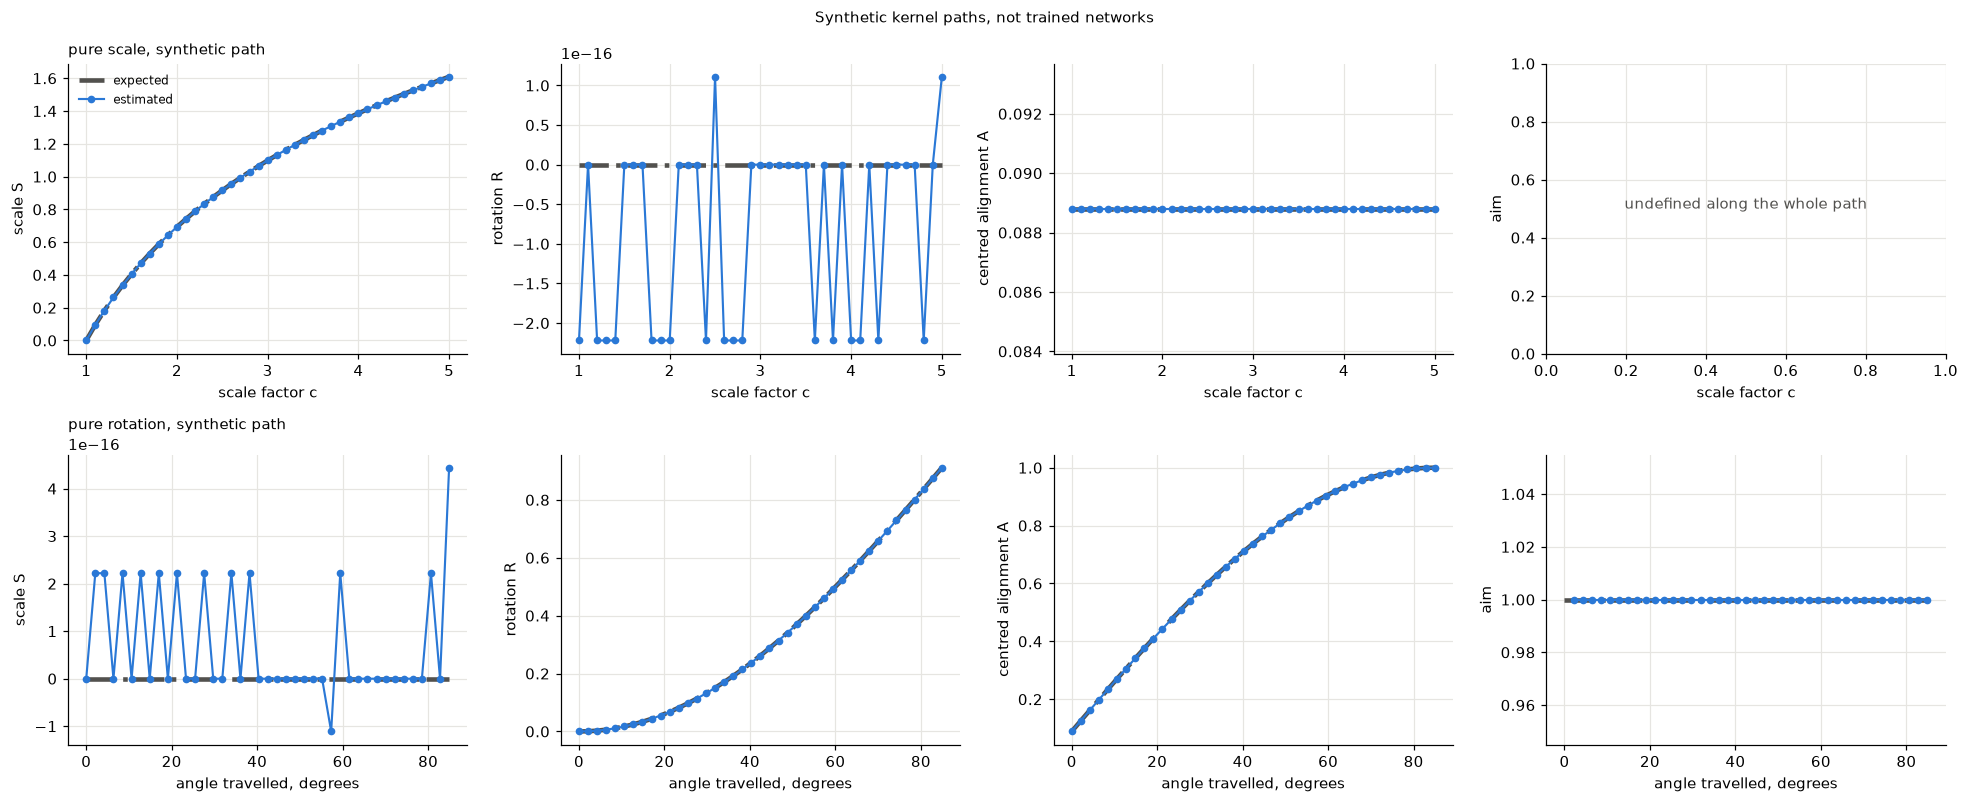

In [35]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7.4))
xs = {"pure scale": (c, "scale factor c"), "pure rotation": (np.degrees(theta), "angle travelled, degrees")}
expected = {
    "pure scale": {"S": np.log(c), "R": np.zeros_like(c), "A": np.full_like(c, ref.A_0), "gamma": None},
    "pure rotation": {"S": np.zeros_like(theta), "R": 1 - np.cos(theta),
                      "A": ref.A_0 * np.cos(theta) + np.sqrt(1 - ref.A_0 ** 2) * np.sin(theta), "gamma": np.ones_like(theta)},
}
for row, name in enumerate(["pure scale", "pure rotation"]):
    x, xlabel = xs[name]
    for col, (key, ylabel) in enumerate([("S", "scale S"), ("R", "rotation R"), ("A", "centred alignment A"), ("gamma", "aim")]):
        ax = axes[row, col]
        if expected[name][key] is not None:
            ax.plot(x, expected[name][key], color=L.GRAY, lw=3, ls="-.", label="expected")
        if not np.all(np.isnan(synthetic[name][key])):
            ax.plot(x, synthetic[name][key], "o-", ms=4, color=L.BLUE, lw=1.4, label="estimated")
        else:
            ax.text(0.5, 0.5, "undefined along the whole path", transform=ax.transAxes, ha="center", color=L.GRAY)
        ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        L.tidy_axes(ax)
        if col == 0:
            ax.set_title(f"{name}, synthetic path", loc="left", fontsize=10)
axes[0, 0].legend(fontsize=8)
fig.suptitle("Synthetic kernel paths, not trained networks", fontsize=10)
fig.tight_layout()

**Figure 7.2. The shares and the eigenvectors on the two paths.** Left: the three shares of the change along the pure rotation path, on a log axis. The residual should sit at rounding level. Middle: the smallest overlap of a matched eigenvector with its predecessor, on both paths. Right: the 22 label angles along the pure rotation path, which should fall to zero as the kernel reaches the target.

The pure rotation path has many new arrivals. That is expected. Each of its 40 steps turns the kernel by about two degrees, and the target has only 22 nonzero eigenvalues, so near the end of the path most of the top 88 eigenvectors belong to eigenvalues close to zero, and they are not well defined. The label angles are the part of E4 that has a known answer on this path.

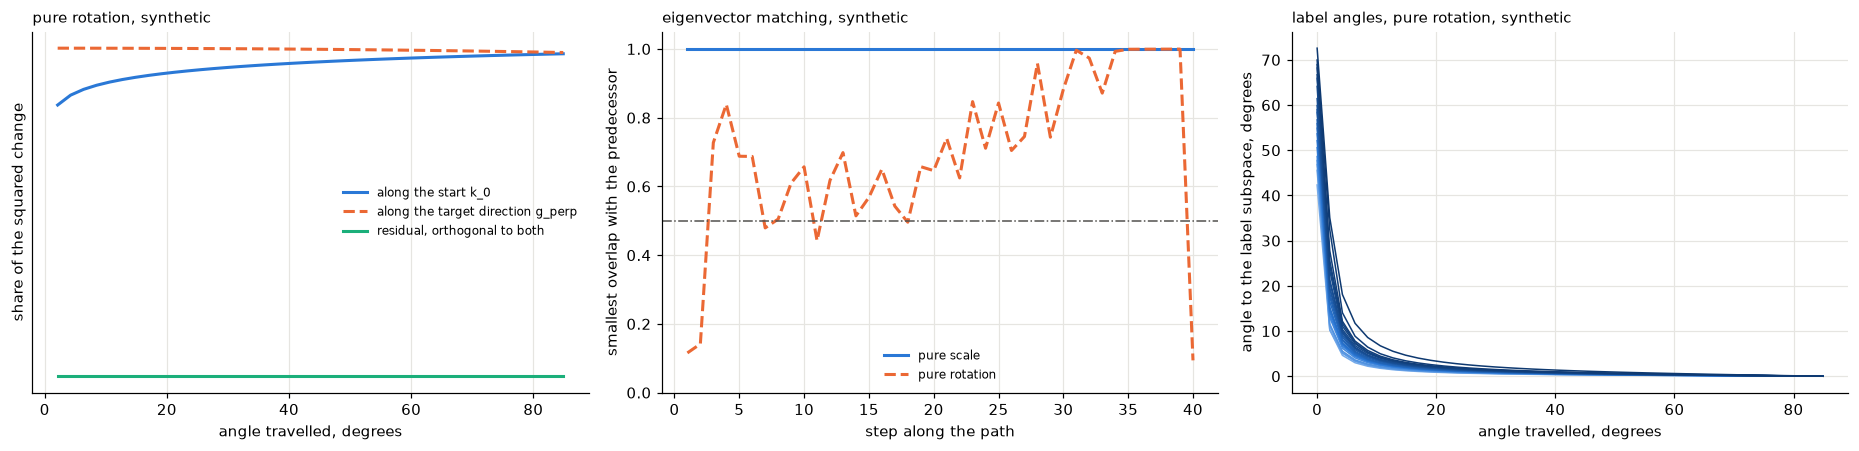

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
x = np.degrees(theta)
for key, colour, ls, name in share_style:
    axes[0].plot(x[1:], np.maximum(r[key][1:], 1e-20), color=colour, ls=ls, label=name)
axes[0].set_yscale("log"); axes[0].set_xlabel("angle travelled, degrees"); axes[0].set_ylabel("share of the squared change")
axes[0].set_title("pure rotation, synthetic", loc="left", fontsize=10)
axes[0].legend(fontsize=8)
axes[1].plot(np.arange(1, n_steps), np.nanmin(s["overlap_prev"][1:], axis=1), color=L.BLUE, label="pure scale")
axes[1].plot(np.arange(1, n_steps), np.nanmin(r["overlap_prev"][1:], axis=1), color=L.ORANGE, ls="--", label="pure rotation")
axes[1].axhline(0.5, color=L.GRAY, lw=1, ls="-.")
axes[1].set_xlabel("step along the path"); axes[1].set_ylabel("smallest overlap with the predecessor")
axes[1].set_ylim(0, 1.05); axes[1].legend(fontsize=8)
axes[1].set_title("eigenvector matching, synthetic", loc="left", fontsize=10)
angl = np.degrees(r["principal_angles_label"])
for j in range(angl.shape[1]):
    axes[2].plot(x, angl[:, j], color=SEQUENTIAL(0.3 + 0.7 * j / angl.shape[1]), lw=1)
axes[2].set_xlabel("angle travelled, degrees"); axes[2].set_ylabel("angle to the label subspace, degrees")
axes[2].set_title("label angles, pure rotation, synthetic", loc="left", fontsize=10)
for ax in axes:
    L.tidy_axes(ax)
fig.tight_layout()

## 8. What this means for the report and the deck

**Scope.** These results come from the 63 runs of the Tier 1 grid and from three traced runs at alpha 1. The plan also lists four traced runs at alpha 0.5 and 2, which are not trained yet. Every statement below about the traced runs holds for alpha 1 only.

**L1, by definition. Settled.** The scale term cannot be recovered from rotation and alignment, and they cannot be recovered from it. Rotation and alignment are tied by the exact identity through the aim. On the traced runs the identity holds to $1.7 \times 10^{-16}$ at every checkpoint (Figure 1.1). On the dense runs it holds to $9.1 \times 10^{-6}$, the precision of their saved float32 kernels. So the three timing variables are best read as the triple of scale, rotation and aim: how big the kernel is, how far it has turned, and how much of the turn points at the target. Given $A_0$, the alignment adds nothing to that triple.

**L2, along a run. Fails as a general claim.** Without decay, scale and rotation move in lockstep: the median $R^2$ of scale on rotation is 0.993 over 20 runs. With decay the lockstep breaks. The median falls below the kill level of 0.9 at eta times decay 0.0001 (0.850), 0.00012 (0.817), 0.001 (0.036) and 0.0012 (0.528). So scale and rotation are one variable only in runs without decay. Alignment is not a function of rotation along a run without decay: the median $R^2$ of alignment on rotation is 0.032, and on the square root of rotation it is 0.086. With the decays of the Tier 1 grid the second of these rises to a median between 0.667 and 0.868.

These shares depend on how the run is sampled. For the decay 0 cell at alpha 1, alignment on rotation gives 0.000 over the 100,000 steps of the grid run and 0.762 over its first 30,000 steps. The alignment rises until about step 10,000 and then falls while rotation keeps growing. Over the same 30,000 steps the traced run gives 0.929, because its log-spaced checkpoints give the early part of the run more weight (Section 4). Any statement about L2 has to name the run length and the checkpoints.

**L3, across runs at the event. Fails.** The plane of alignment on scale and rotation at the generalisation event explains 0.172 of the variance over 45 runs, with a 95 percent bootstrap interval of 0.024 to 0.568. That is below the kill level of 0.5, and only 5.6 percent of the bootstrap resamples go above it. The aim alone explains 0.976, rotation and the aim together explain 0.988, and the two terms of the identity explain all of it. So at the event the alignment is set by the aim. The correlations at the event are 0.54 between scale and rotation, 0.07 between rotation and alignment, minus 0.31 between scale and alignment, and 0.99 between alignment and aim.

**L4, in matrix space. Fails, and the turn goes somewhere the plan did not expect.** The kernel does not turn towards the target. The residual share of the squared change stays between 0.937 and 1.000 on all three traced runs (Figure 5.1), above the plan's floor of 0.9. The share along the target direction reaches at most 0.007, 0.027 and 0.010 for decay 0, 0.0003 and 0.001.

The plan expected the residual to lie mostly in the difference subspace. It does not. At step 30,000 the squared norm of the residual lies 0.21 to 0.22 in the block of functions of $a$ alone and 0.21 to 0.25 in the block of functions of $b$ alone, against 0.011 to 0.032 in the difference block and 0.003 to 0.005 in the sum block (Figure 5.3). A further 0.15 to 0.19 lies outside all four subspaces. The leading residual eigenvector puts 0.32 to 0.41 of its energy on $a$ and 0.53 to 0.63 on $b$, and less than the chance level of 0.086 on the sum or the difference (Figure 5.2). On the torus the residual is a cross along zero offset in $a$ and in $b$ (Figure 5.4), which is how functions of $a$ alone and of $b$ alone look after the torus average. The difference block does grow during training and ends larger than the sum block, as the plan reasoned. It is a few percent of the turn.

So most of the turn reshapes how the kernel weights functions of $a$ alone and of $b$ alone, and very little of it points at the labels. That fits the small aim, 0.07 to 0.17 at the end of the traced runs.

**E4, the eigenvectors. The label structure is there, in a block with small eigenvalues.** The leading 44 eigenvectors are functions of $a$ alone and of $b$ alone throughout. The largest relative gap in the spectrum sits right after index 43, at 0.69 at step 0 and at 0.57 to 0.68 at step 30,000 (Figure 6.1). The sum and difference functions rise out of the bulk into indices 44 to 87. Their mean energy there goes from 0.096 and 0.091 at step 0, the chance level, to 0.31 to 0.41 for the sum and 0.25 to 0.39 for the difference at step 30,000 (Figure 6.3). At step 0 one of the 22 label angles is below 45 degrees. At step 30,000 there are 18, 22 and 21 for decay 0, 0.0003 and 0.001 (Figure 6.5). Decay 0.0003 is fastest: all 22 angles are below 45 degrees by step 9,500, close to its generalisation at step 8,500.

This explains why the Frobenius measures see so little of the labels. For decay 0 at step 30,000, indices 44 to 87 have eigenvalues between 1.3 and 2.3, against 7.1 to 35.8 for indices 0 to 43. The rotation, the alignment and the three shares all weight directions by the square of their eigenvalue, so the block of functions of $a$ and $b$ dominates them. The report should say so when it reads the alignment as a measure of feature learning.

The matching conventions behave. The median overlap with the previous checkpoint is 0.96 to 0.99, and there is no new arrival among indices 0 to 43. Over the whole run the vectors of that block mix slowly: a chain of matches ends with a median overlap of 0.17 to 0.18 with its step 0 origin (Figure 6.4). A single eigenvector can be followed over short spans only.

**E5, the synthetic control. Passed after one fix.** Every estimator reproduces the known answer to rounding on both paths. The control found that the first tracer turned rounding noise into an aim on a purely rescaled kernel. That is now fixed, and the saved traces did not change.

**Appendix. The two changes of 24 September matter.** The summed-output kernel that the report's Methods line used to name gives a scale term of 0.86 against 1.62 for decay 0, minus 0.19 against 0.67 for decay 0.0003, and minus 0.92 against minus 0.42 for decay 0.001 at step 30,000. Its rotation is about twice as large. So the kernel definition changes the numbers the report's claims rest on. The probe change moves the pooled terms much less: at step 30,000 the alignment moves by 0.005 to 0.008 and the scale term by at most 0.015. The two parts of the probe differ from each other at step 0 already. The test part starts at an alignment of 0.39 and the training part at 0.12. That gap comes from the size and label make-up of each part, because it is there before any training.

**For the report.**

1. Present the three timing variables as scale, rotation and aim, with the identity, and say that the alignment follows from rotation and aim given $A_0$.
2. Any claim that scale and rotation move together holds only without decay, and it has to name the run length and the checkpoints.
3. The terms at the generalisation event are not linearly dependent. The alignment at the event is set by the aim.
4. The kernel turns mostly by reweighting functions of $a$ alone and of $b$ alone. The label structure appears in a block of smaller eigenvalues, which the Frobenius measures underweight.

**Scenes for the deck, in the order to build them.**

1. `OffPlaneShare`. The three shares, then the residual by block and on the torus. Its message is that the kernel turns away from the plane of start and target, into functions of $a$ and $b$.
2. `EigenvectorsTurn`. The two blocks of the spectrum, the sum and difference functions rising into indices 44 to 87, and the label angles falling. It should draw subspace energies and angles, and follow single eigenvectors only over short spans.
3. `FormulaLive`. The identity with its numbers read from a trace at a moving step.

**Still to do.** Trace the four cells at alpha 0.5 and 2 (step 3 of the plan) and repeat Sections 4 to 6 on them. Add the numpy kernel of E6 (step 5). The group still has to settle the grokking-time definition (Section 11 of the plan).

## Appendix. Why the kernel and the probe changed on 24 September 2026

Two differences between the report and the code were found while this study was set up. Section 11 of the plan records how each one was settled.

**A.1 The kernel.** The report's Methods line called the probe kernel the gradient of the summed output $\sum_c f_c$. The report's Introduction, the proposal and the code use the sum over outputs of the per-output kernels, $K(x, x') = \sum_c \langle\nabla_\theta f_c(x), \nabla_\theta f_c(x')\rangle$. That is the trace of the matrix-valued NTK of Jacot, Gabriel and Hongler (2018). By their Theorem 1 (arXiv v4) the two agree in the infinite-width limit at initialisation. The report line was corrected. The figure shows how far apart the two kernels are on the traced runs, rebuilt from the saved weights at every eighth checkpoint.

In [37]:
import torch
from torch.func import functional_call, vmap, jacrev


def two_kernels(a, t, x_probe, width=100, p=23):
    # The trace kernel and the summed-output kernel at checkpoint t, from the saved weights.
    model = L.NTKMLP(2 * p, width, p)
    params = {"W1": torch.tensor(a["W1"][t]), "W2": torch.tensor(a["W2"][t])}
    jac = vmap(jacrev(lambda q, xi: functional_call(model, q, xi[None])[0]), (None, 0))(params, x_probe)
    J = torch.cat([j.flatten(2) for j in jac.values()], 2)
    summed = J.sum(1)
    return torch.einsum("acp,bcp->ab", J, J).double().numpy(), (summed @ summed.T).double().numpy()


def terms(K, K0, G):
    Kc, K0c = kernels.centre(K), kernels.centre(K0)
    k, k0 = kernels.unit(Kc), kernels.unit(K0c)
    return np.log(np.linalg.norm(Kc) / np.linalg.norm(K0c)), 1 - np.sum(k * k0), np.sum(k * kernels.unit(G))


kernel_compare = {}
for _, ek in TRACED:
    a, tracer = traces[ek], tracers[ek]
    idx = sorted(set(range(0, len(a["step"]), 8)) | {len(a["step"]) - 1})
    base_trace, base_summed = two_kernels(a, 0, tracer.x_probe)
    out = []
    for t in idx:
        Kt, Ks = two_kernels(a, t, tracer.x_probe)
        check = np.abs(Kt - a["K"][t]).max() / np.abs(a["K"][t]).max()
        out.append((a["step"][t], *terms(Kt, base_trace, tracer.G), *terms(Ks, base_summed, tracer.G), check))
    kernel_compare[ek] = np.array(out)
    last = kernel_compare[ek][-1]
    print(f"{schemas[ek]['run']}: rebuilt trace kernel against the saved kernel, largest relative difference "
          f"{kernel_compare[ek][:, 7].max():.1e}")
    print(f"   at step {int(last[0])}: trace kernel S {last[1]:+.3f} R {last[2]:.4f} A {last[3]:.4f} | "
          f"summed-output kernel S {last[4]:+.3f} R {last[5]:.4f} A {last[6]:.4f}")

trace_N100_a1_wd0_s0: rebuilt trace kernel against the saved kernel, largest relative difference 0.0e+00
   at step 30000: trace kernel S +1.621 R 0.0704 A 0.1086 | summed-output kernel S +0.858 R 0.1650 A 0.1012


trace_N100_a1_wd0.0003_s0: rebuilt trace kernel against the saved kernel, largest relative difference 0.0e+00
   at step 30000: trace kernel S +0.665 R 0.0723 A 0.1441 | summed-output kernel S -0.188 R 0.1455 A 0.1852


trace_N100_a1_wd0.001_s0: rebuilt trace kernel against the saved kernel, largest relative difference 0.0e+00
   at step 30000: trace kernel S -0.415 R 0.0642 A 0.1195 | summed-output kernel S -0.919 R 0.0990 A 0.1276


**Figure A.1. The trace kernel against the summed-output kernel.** The columns are scale, rotation and alignment. Solid lines use the trace kernel, which the report now defines. Dashed lines use the kernel of the summed output. The two start together and separate during training. Under decay the scale term even changes sign.

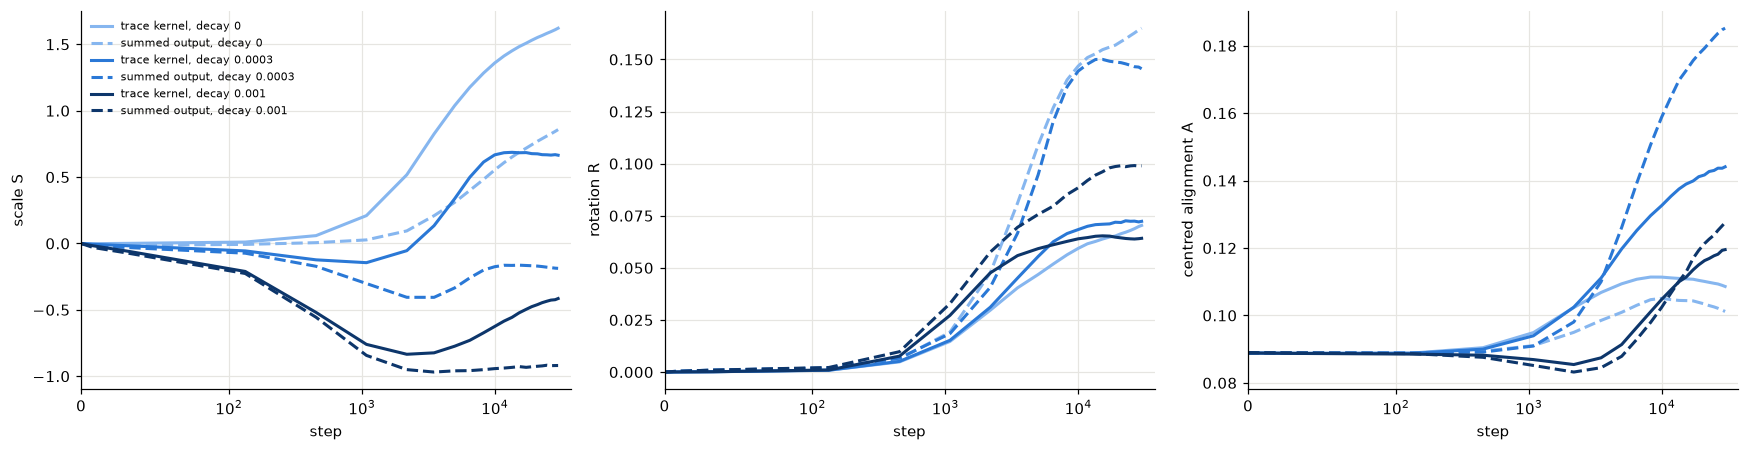

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for _, ek in TRACED:
    v = kernel_compare[ek]
    for col, (j_trace, j_sum, ylabel) in enumerate([(1, 4, "scale S"), (2, 5, "rotation R"), (3, 6, "centred alignment A")]):
        axes[col].plot(v[:, 0], v[:, j_trace], color=TRACE_COLOURS[ek], label=f"trace kernel, {label(ek)}")
        axes[col].plot(v[:, 0], v[:, j_sum], color=TRACE_COLOURS[ek], ls="--", label=f"summed output, {label(ek)}")
        axes[col].set_ylabel(ylabel)
for ax in axes:
    ax.set_xlabel("step")
    L.log_step_axis(ax)
    L.tidy_axes(ax)
axes[0].legend(fontsize=7)
fig.tight_layout()

**A.2 The probe.** The report asks for a probe with both training and test pairs. The code used the first 256 training pairs. No paper settles the choice. Kumar et al. (2024) evaluate their alignment on the test set (Section 5, arXiv v3), which supports the report, so the code now follows it. The dense runs of `kernel_snapshots.py` still use the training-pair probe, and they have the same weights as the traced runs. So the figure below compares the two probes on identical networks. Solid lines are the mixed probe and dashed lines the training-pair probe.

                         run     probe   S end   R end     A_0   A end
        trace_N100_a1_wd0_s0     mixed   1.621  0.0704  0.0888  0.1086
        trace_N100_a1_wd0_s0  training   1.606  0.0685  0.0903  0.1135
   trace_N100_a1_wd0.0003_s0     mixed   0.665  0.0723  0.0888  0.1441
   trace_N100_a1_wd0.0003_s0  training   0.662  0.0737  0.0903  0.1490
    trace_N100_a1_wd0.001_s0     mixed  -0.415  0.0642  0.0888  0.1195
    trace_N100_a1_wd0.001_s0  training  -0.420  0.0669  0.0903  0.1275


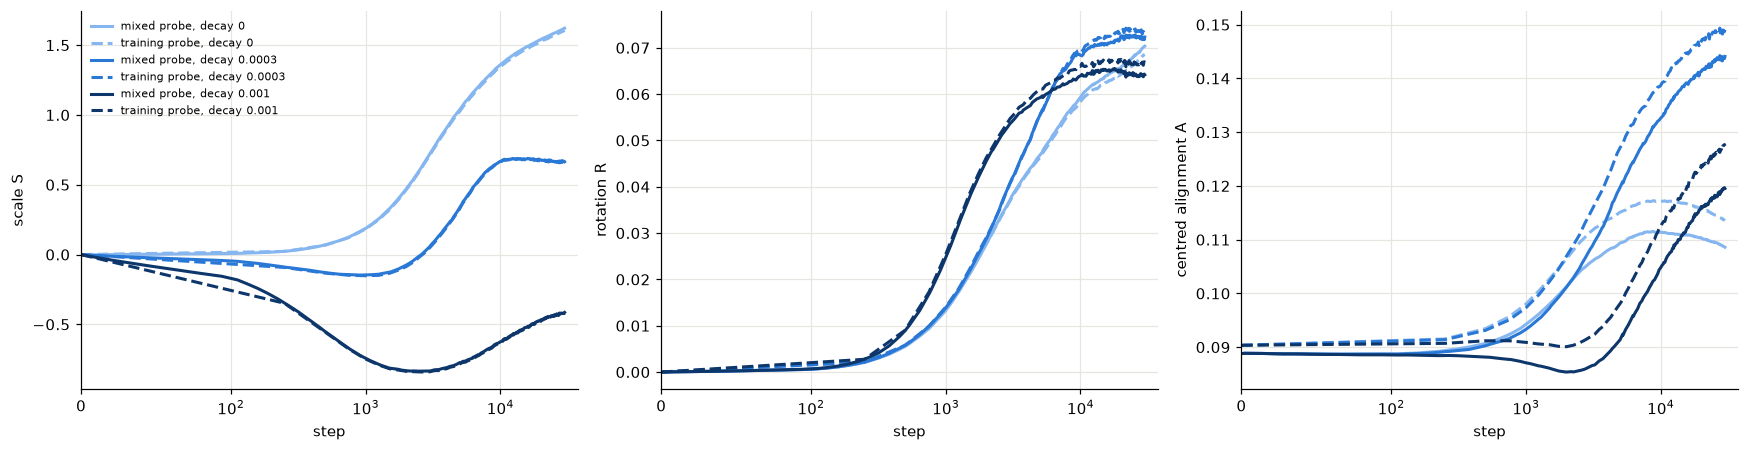

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
print(f"{'run':>28} {'probe':>9} {'S end':>7} {'R end':>7} {'A_0':>7} {'A end':>7}")
for _, ek in TRACED:
    mixed, old = trace_runs[ek]["history"], dense[ek]["history"]
    for col, (key, ylabel) in enumerate([("S_c", "scale S"), ("R_c", "rotation R"), ("A_t", "centred alignment A")]):
        axes[col].plot(mixed["step"], mixed[key], color=TRACE_COLOURS[ek], label=f"mixed probe, {label(ek)}")
        axes[col].plot(old["step"], old[key], color=TRACE_COLOURS[ek], ls="--", label=f"training probe, {label(ek)}")
        axes[col].set_ylabel(ylabel)
    for probe, h in [("mixed", mixed), ("training", old)]:
        print(f"{schemas[ek]['run']:>28} {probe:>9} {h['S_c'][-1]:7.3f} {h['R_c'][-1]:7.4f} {h['A_t'][0]:7.4f} {h['A_t'][-1]:7.4f}")
for ax in axes:
    ax.set_xlabel("step")
    L.log_step_axis(ax)
    L.tidy_axes(ax)
axes[0].legend(fontsize=7)
fig.tight_layout()